In [60]:
import geopandas as gpd
import pandas as pd

basline_blocks = gpd.read_file('./data/gatchina/blocks_agg_with_indicators.geojson')
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,is_living,...,area_accessibility,fsi,gsi,mxi,l,osr,share_living,share_non_living,morphotype,geometry
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,6.0,...,10.063987,0.012109,0.008829,0.091908,1.371459,81.852753,0.126048,1.245411,individual residential,"POLYGON ((30.09367 59.55207, 30.09375 59.55215..."
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,13.0,...,10.210398,0.212156,0.036428,0.712492,5.824002,4.541808,4.149554,1.674447,mid-rise,"POLYGON ((30.09448 59.56164, 30.09448 59.56164..."
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,15.0,...,8.669212,0.303551,0.056576,0.786029,5.365401,3.107955,4.217362,1.148039,mid-rise,"POLYGON ((30.12546 59.58002, 30.12541 59.57998..."
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,2.0,...,7.467434,0.173716,0.075903,0.198114,2.288643,5.319595,0.453413,1.835230,low-rise model,"POLYGON ((30.12501 59.56588, 30.12497 59.56582..."
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,2.0,...,8.285434,0.156696,0.071648,0.095598,2.187029,5.924533,0.209075,1.977953,low-rise model,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,..."


In [61]:
cols = [
    'residential','business','recreation','industrial','transport','special',
    'agriculture','land_use','share','footprint_area','build_floor_area',
    'living_area','non_living_area','population','site_area','fsi','gsi',
    'mxi','l','morphotype','area_accessibility', 'geometry'
]
basline_blocks = basline_blocks[cols]


In [62]:
from catboost import CatBoostRegressor
model = CatBoostRegressor()
model.load_model('./data/catboost_model.cbm')  # модель на лог-цене
print(len(model.feature_names_))

121


In [63]:
feature_cols = [
'residential','business','recreation','industrial','transport','special',
'agriculture','land_use','share','footprint_area','build_floor_area',
'living_area','non_living_area','population','site_area','fsi','gsi',
'mxi','l','morphotype','area_accessibility'
]
cat_features = ['land_use', 'morphotype']
numeric_feats = [c for c in feature_cols if c not in cat_features]

In [64]:
basline_blocks['residential'] = basline_blocks['residential'].astype('float64')

In [65]:
# import geopandas as gpd
# import pandas as pd

# # 1. Переводим в метрическую CRS
# baseline_blocks_metric = basline_blocks.to_crs(basline_blocks.estimate_utm_crs()).copy()

# # 2. Считаем площадь в м2 и гектарах
# baseline_blocks_metric["calc_area_m2"] = baseline_blocks_metric.geometry.area
# baseline_blocks_metric["calc_area_ha"] = baseline_blocks_metric["calc_area_m2"] / 10_000

# # 3. Переводим site_area в гектары
# baseline_blocks_metric["site_area_ha"] = baseline_blocks_metric["site_area"] / 10_000

# # 4. Сравниваем
# baseline_blocks_metric["area_diff_ha"] = (
#     baseline_blocks_metric["calc_area_ha"] - baseline_blocks_metric["site_area_ha"]
# )

# baseline_blocks_metric["area_diff_pct"] = (
#     baseline_blocks_metric["area_diff_ha"] / baseline_blocks_metric["site_area_ha"] * 100
# )

# # 5. Сводка
# print(
#     baseline_blocks_metric[
#         ["site_area_ha", "calc_area_ha", "area_diff_ha", "area_diff_pct"]
#     ].describe()
# )

# # 6. Самые большие расхождения
# comparison_ha = baseline_blocks_metric[
#     ["site_area_ha", "calc_area_ha", "area_diff_ha", "area_diff_pct", "geometry"]
# ].copy()

# comparison_ha["abs_area_diff_pct"] = comparison_ha["area_diff_pct"].abs()
# comparison_ha.sort_values("abs_area_diff_pct", ascending=False).head(10)


In [67]:
# удаляем старую колонку
basline_blocks = basline_blocks.drop(columns=["site_area"], errors="ignore").copy()

# пересчитываем площадь в метрической CRS
basline_blocks_metric = basline_blocks.to_crs(basline_blocks.estimate_utm_crs()).copy()
basline_blocks["site_area"] = basline_blocks_metric.geometry.area.values


In [68]:
basline_blocks.iloc[7]

residential                                                         0.0
business                                                            0.0
recreation                                                          0.0
industrial                                                     0.727595
transport                                                      0.000757
special                                                        0.200502
agriculture                                                         0.0
land_use                                             LandUse.INDUSTRIAL
share                                                          0.727595
footprint_area                                              3990.876381
build_floor_area                                            3990.876381
living_area                                                         0.0
non_living_area                                             3990.876381
population                                                      

In [8]:
from catboost import CatBoostRegressor

from urbanomy.methods.land_value_modeling import LandPriceEstimator

estimator = LandPriceEstimator(
    model=model,
    orig_features=numeric_feats+cat_features,
    categorical_features=cat_features,
    blocks=basline_blocks, #or blocks_198
)
blocks_pred = estimator.predict()

blocks_pred.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,population,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry,site_area,land_value
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,30.0,0.012109,0.008829,0.091908,1.371459,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",215420.389645,2.918098e+08
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,2000.0,0.212156,0.036428,0.712492,5.824002,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",108166.972589,3.119623e+08
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,2275.0,0.303551,0.056576,0.786029,5.365401,mid-rise,8.669212,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",77911.495727,2.421744e+08
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,134.0,0.173716,0.075903,0.198114,2.288643,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",32058.270586,8.120294e+07
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,56.0,0.156696,0.071648,0.095598,2.187029,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",30779.356283,7.602283e+07


count       347.000000
mean     220050.592193
std      119630.263665
min           0.000000
25%      108374.167284
50%      240344.072477
75%      328479.077353
max      599730.537776
Name: land_value_per_100m2, dtype: float64


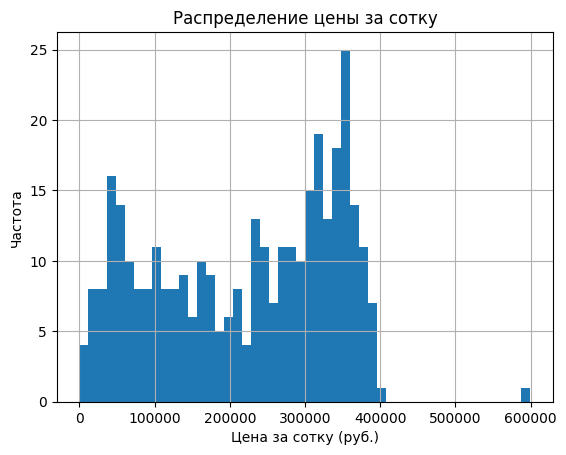

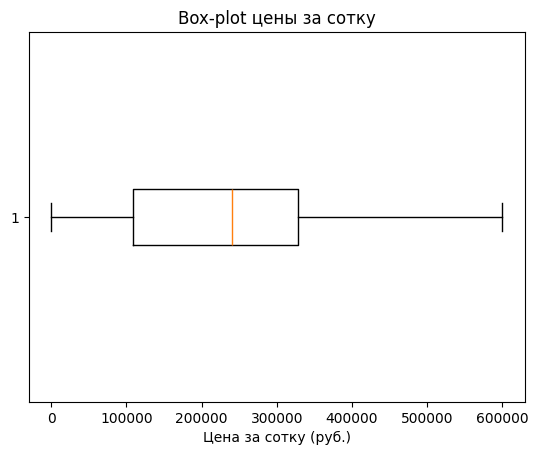

In [9]:
import numpy as np
import matplotlib.pyplot as plt
# 1) Цена за сотку (100 м²)
blocks_pred["land_value_per_100m2"] = blocks_pred["land_value"] / blocks_pred["site_area"] * 100

# 2) Заменяем inf на NaN
blocks_pred = blocks_pred.replace([np.inf, -np.inf], np.nan)
blocks_pred = blocks_pred.fillna(0)

# 3) Удаляем выбросы: оставляем данные до 99-го перцентиля
p99 = blocks_pred["land_value_per_100m2"].quantile(0.99)
blocks_clean = blocks_pred[blocks_pred["land_value_per_100m2"] <= p99].copy()

print(blocks_clean["land_value_per_100m2"].describe())

# 4) Гистограмма после очистки
plt.figure()
blocks_clean["land_value_per_100m2"].dropna().hist(bins=50)
plt.xlabel("Цена за сотку (руб.)")
plt.ylabel("Частота")
plt.title("Распределение цены за сотку")
plt.show()

# 5) Box-plot после очистки
plt.figure()
plt.boxplot(blocks_clean["land_value_per_100m2"].dropna(), vert=False)
plt.xlabel("Цена за сотку (руб.)")
plt.title("Box-plot цены за сотку")
plt.show()



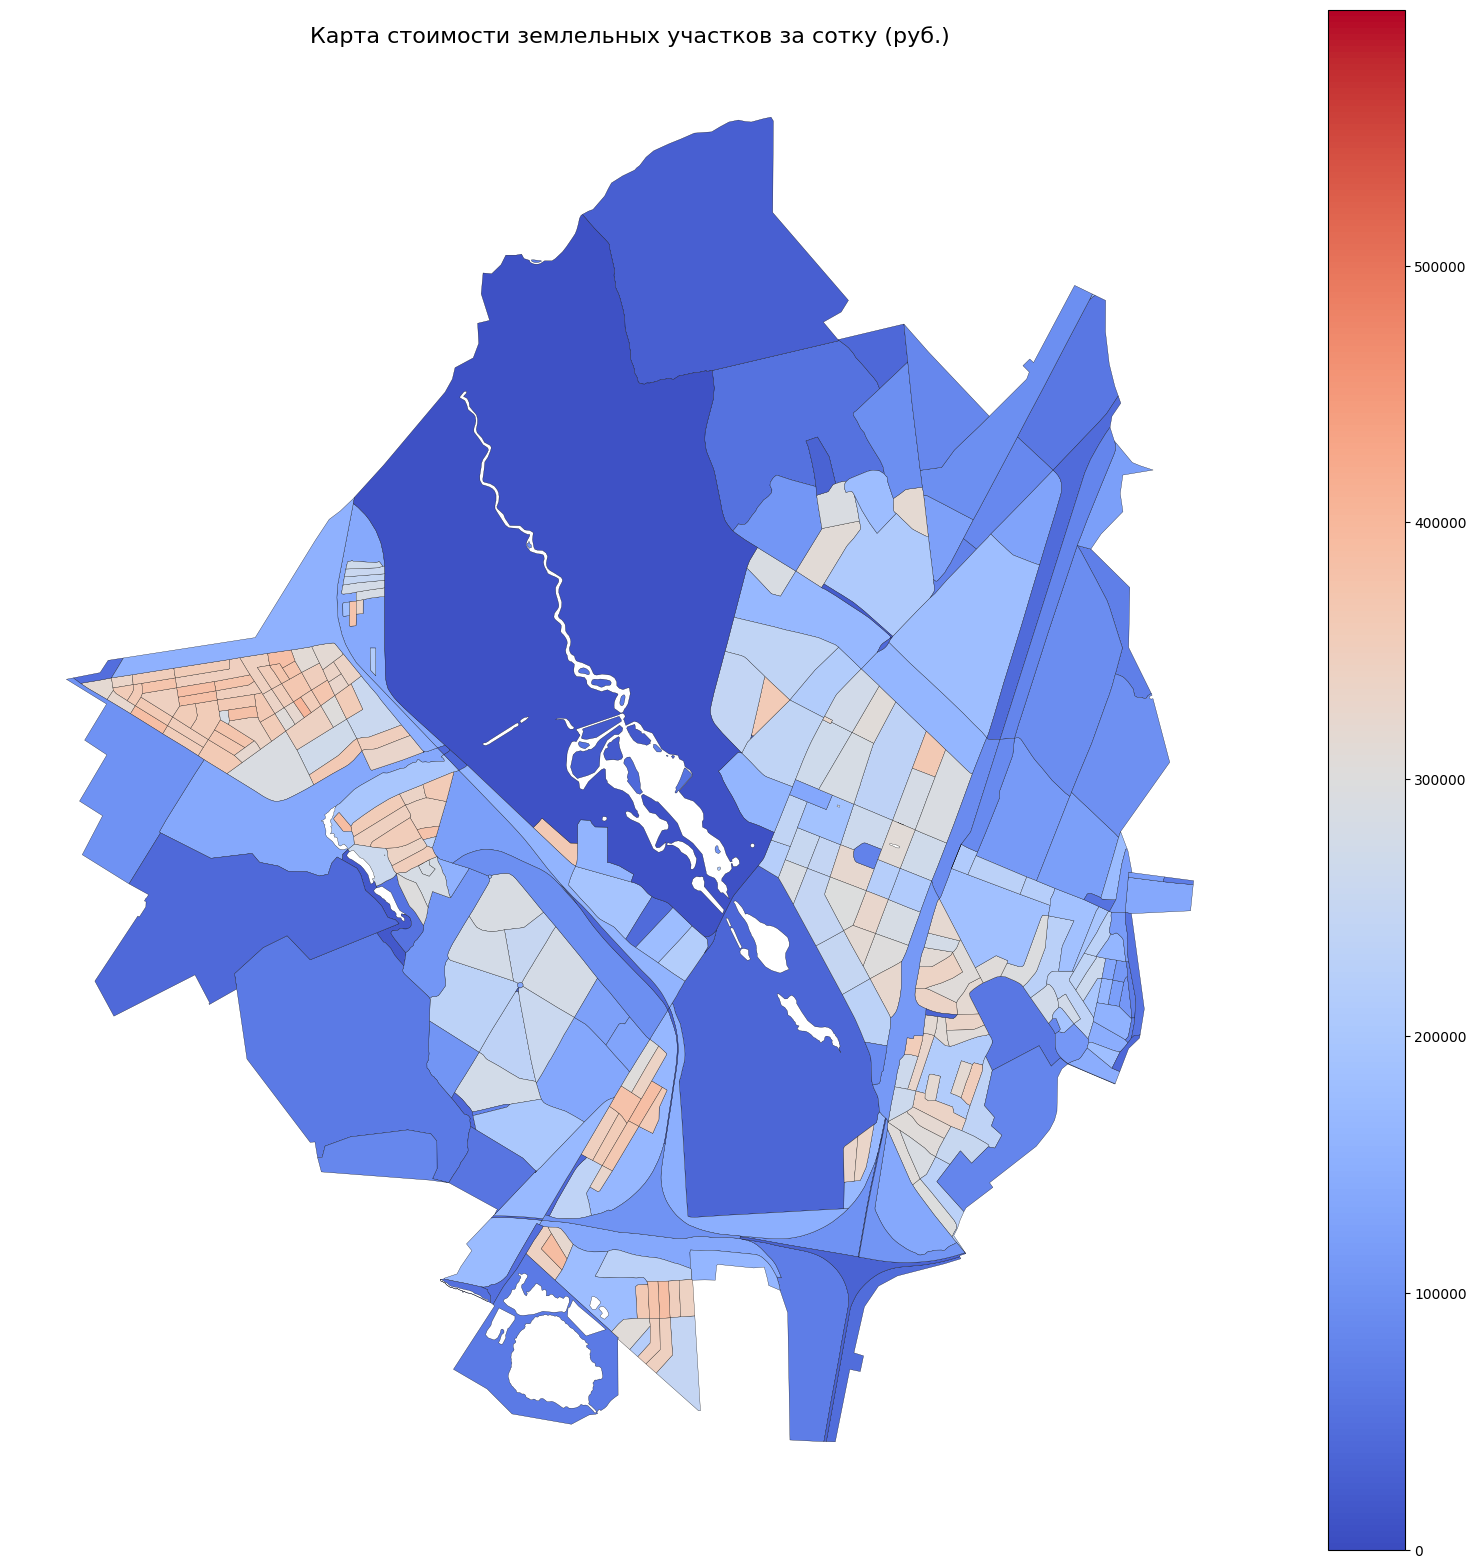

In [10]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value_per_100m2',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости землельных участков за сотку (руб.)', fontsize=16)

plt.show()

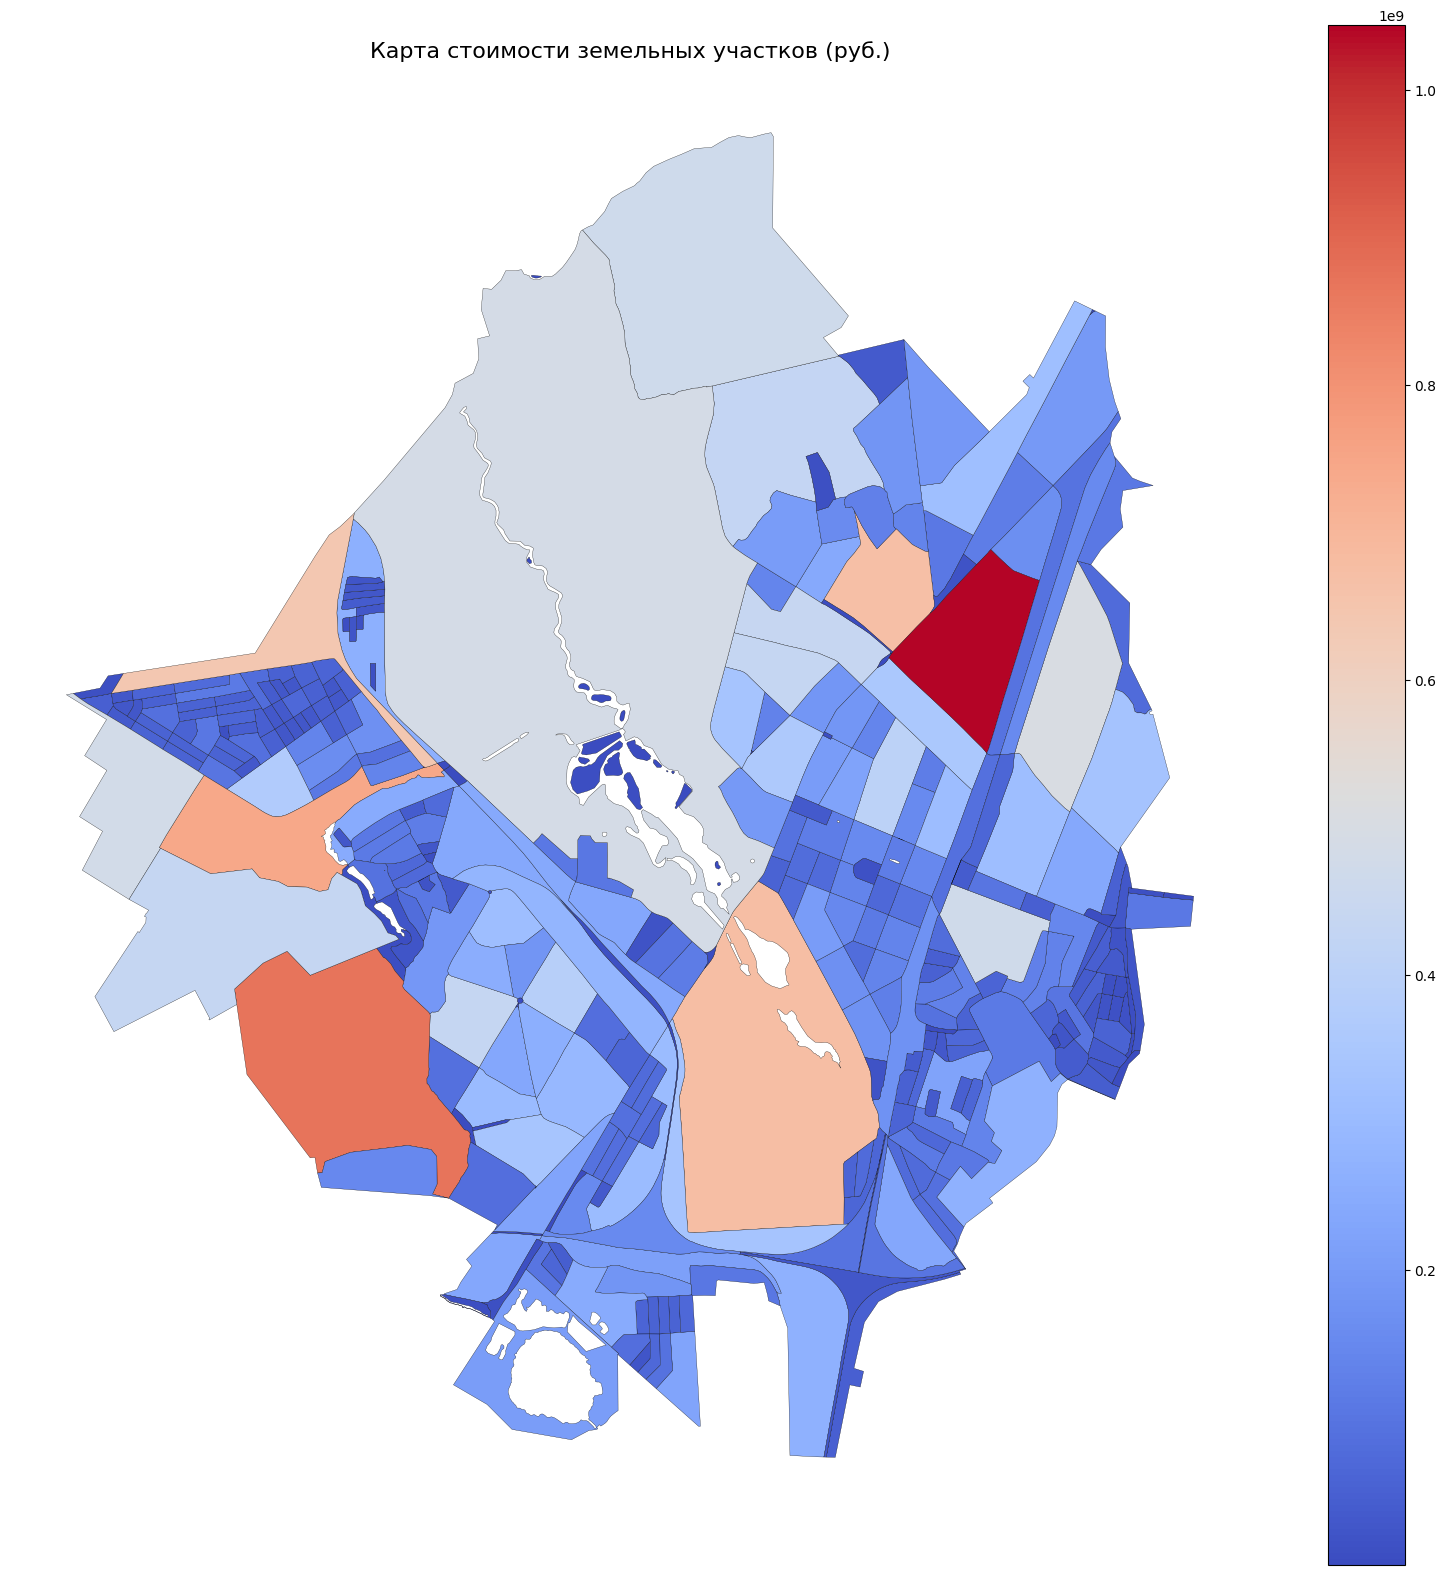

In [11]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости земельных участков (руб.)', fontsize=16)

plt.show()

In [12]:
blocks_clean["id"] = blocks_clean.index

In [13]:
# blocks_clean.to_file("./data/blocks_clean_gatchina.geojson", driver="GeoJSON")

In [14]:
# blocks_clean.explore()

/tmp/ipykernel_43711/3388054100.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  blocks_clean.loc[blocks_clean["id"]==86].centroid.plot(


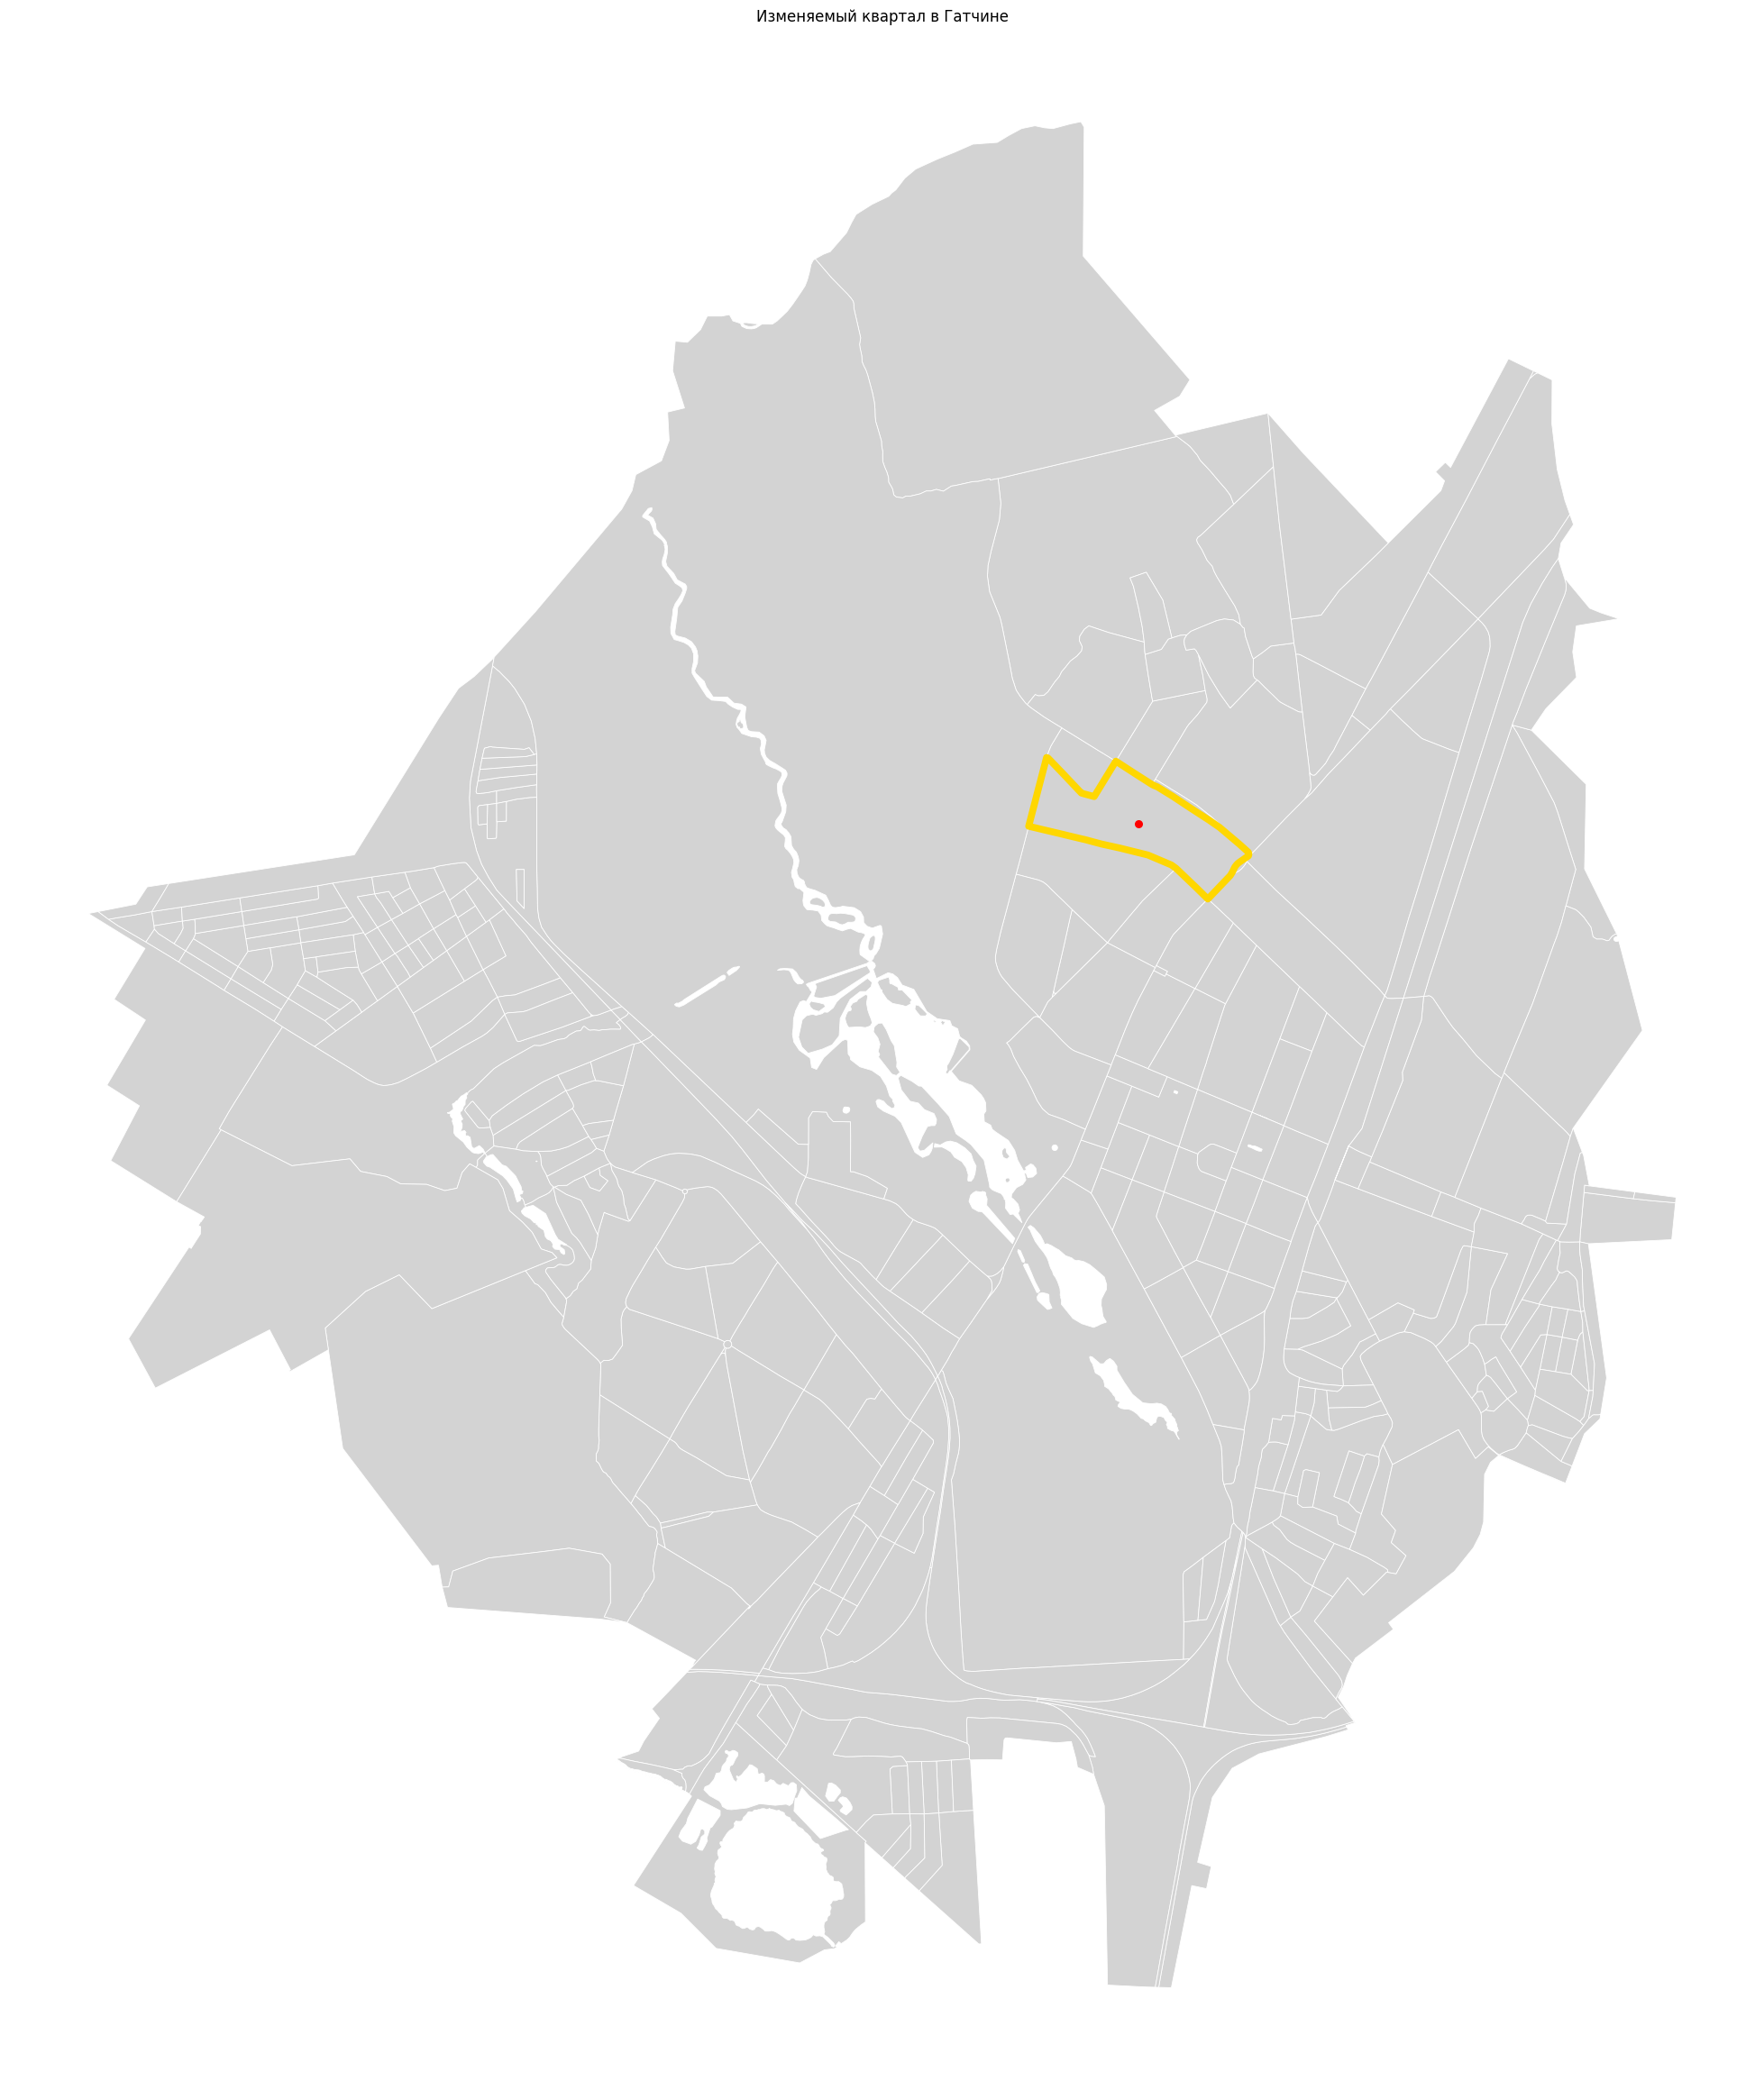

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(25, 35))
blocks_clean.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.6)  # фон
blocks_clean.loc[blocks_clean["id"]==86].plot(
    ax=ax, color="none", edgecolor="gold", linewidth=5.5
)
blocks_clean.loc[blocks_clean["id"]==86].centroid.plot(
     ax=ax, color="red", markersize=30, zorder=3
 )

ax.set_title("Изменяемый квартал в Гатчине")
ax.axis("off")
plt.show()

In [16]:
target_idx = 86

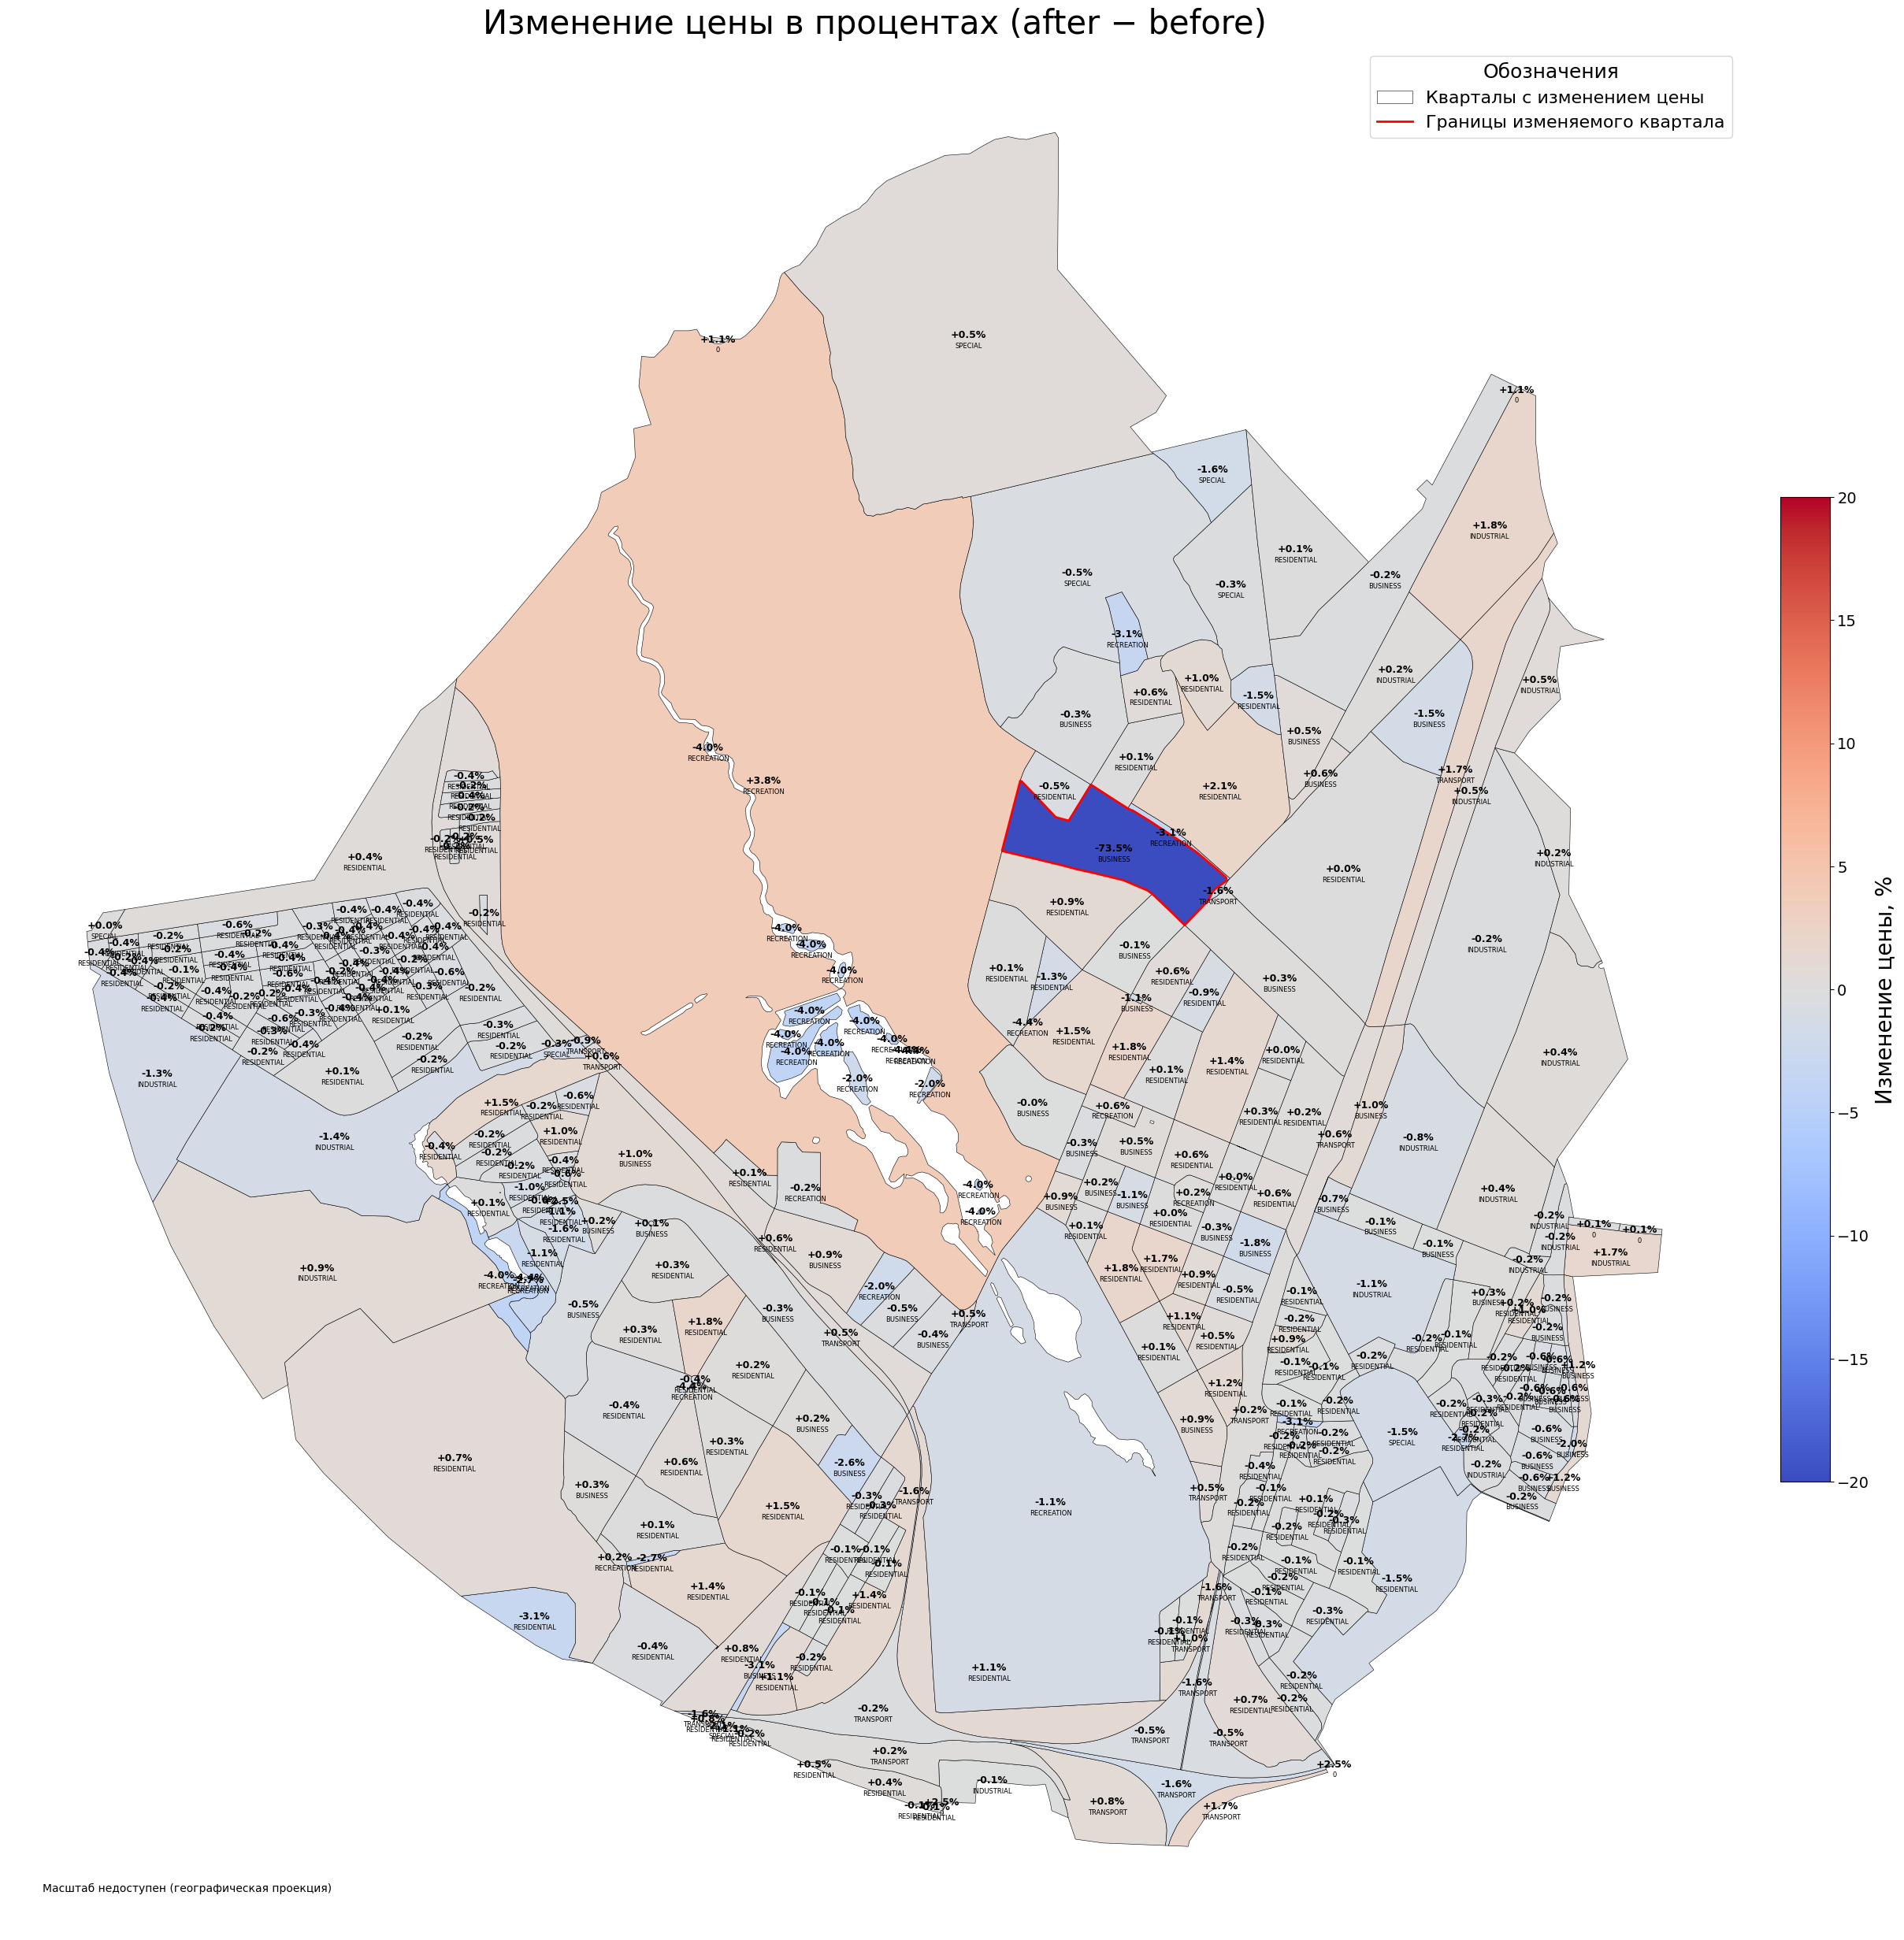


Статистика по кварталам в контексте (|Δ₽| > 1e-09):

Изменяемый квартал:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
86 | BUSINESS | 447 165 384 ₽ → 118 479 530 ₽ | -328 685 854 ₽ | -73.5%

Кварталы в границах проекта:
Нет кварталов проекта с изменениями выше порога.

Кварталы в контексте:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
245 | TRANSPORT | 267 230 431 ₽ → 269 491 595 ₽ | +2 261 164 ₽ | +0.8%
294 | TRANSPORT | 29 278 017 ₽ → 28 805 081 ₽ | -472 936 ₽ | -1.6%
115 | RESIDENTIAL | 54 414 357 ₽ → 54 358 090 ₽ | -56 267 ₽ | -0.1%
313 | RESIDENTIAL | 68 280 249 ₽ → 68 209 644 ₽ | -70 605 ₽ | -0.1%
308 | 0 | 13 362 ₽ → 13 692 ₽ | +330 ₽ | +2.5%
314 | INDUSTRIAL | 107 551 180 ₽ → 107 426 653 ₽ | -124 527 ₽ | -0.1%
224 | TRANSPORT | 105 939 347 ₽ → 105 411 805 ₽ | -527 542 ₽ | -0.5%
295 | TRANSPORT | 1 358 745 ₽ → 1 336 797 ₽ | -21 948 ₽ | -1.6%
5 | TRANSPORT | 65 092 073 ₽ → 65 767 573 ₽ | +675 500 ₽ | +1.0%
225 | TRANSPORT | 46 127 505 ₽ → 46 926 141 ₽ | +798 636 ₽ | +1.7%


In [17]:
from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    plot_scenario_impact,
    transfer_baseline_prices,
)

# Все снесли - ничего не осталось
blocks_after = blocks_clean.copy()
changes = {
        # Структура использования территории
        "residential": 0.0,
        "business": 0.0,
        "recreation": 0.0,
        "industrial": 0.0,
        "transport": 0.0,
        "special": 0.0,
        "agriculture": 0.0,
        "share": 1.0,

    
    "footprint_area": 0.0,   
    "build_floor_area": 0.0,  
    "living_area": 0.0,      
    "non_living_area": 0.0,  
    "population": 0.0,                

    
    "fsi": 0.0,                         
    "gsi": 0.0,                        
    "l": 0.0,                          
                    

        
        "morphotype": "low-rise non-residential",
}



modifier = ScenarioTEPModifier(blocks_after)
blocks_before = modifier.apply(target_idx, changes)

# 1) Предсказание стоимости до/после
before_estimator = LandPriceEstimator(model=model, blocks=blocks_before, use_service_features=False,)
after_estimator = LandPriceEstimator(model=model, blocks=blocks_after, use_service_features=False,)

blocks_before_pred = before_estimator.predict()
blocks_before_pred["land_value_per_100m2"] = blocks_before_pred["land_value"] / blocks_before_pred["site_area"] * 100

blocks_after_pred = after_estimator.predict()
blocks_after_pred["land_value_per_100m2"] = blocks_after_pred["land_value"] / blocks_after_pred["site_area"] * 100

blocks_full_value = transfer_baseline_prices(
    after_blocks=blocks_before_pred,
    before_blocks=blocks_after_pred,
    scenario_mode=False,
)

blocks_full_value = blocks_full_value.replace([np.inf, -np.inf], np.nan)
blocks_full_value = blocks_full_value.fillna(0)

# 3) Только визуализация и статистика по процентным изменениям
scenario_result = plot_scenario_impact(
    blocks=blocks_full_value,
    target_idx=target_idx,          
    target_id_column="id",   # если колонка называется иначе — укажи здесь
    figsize=(25, 35),
)

In [18]:
# blocks_after.to_file('./data/test/gatchina_RESIDENTIAL.geojson', driver='GeoJSON')

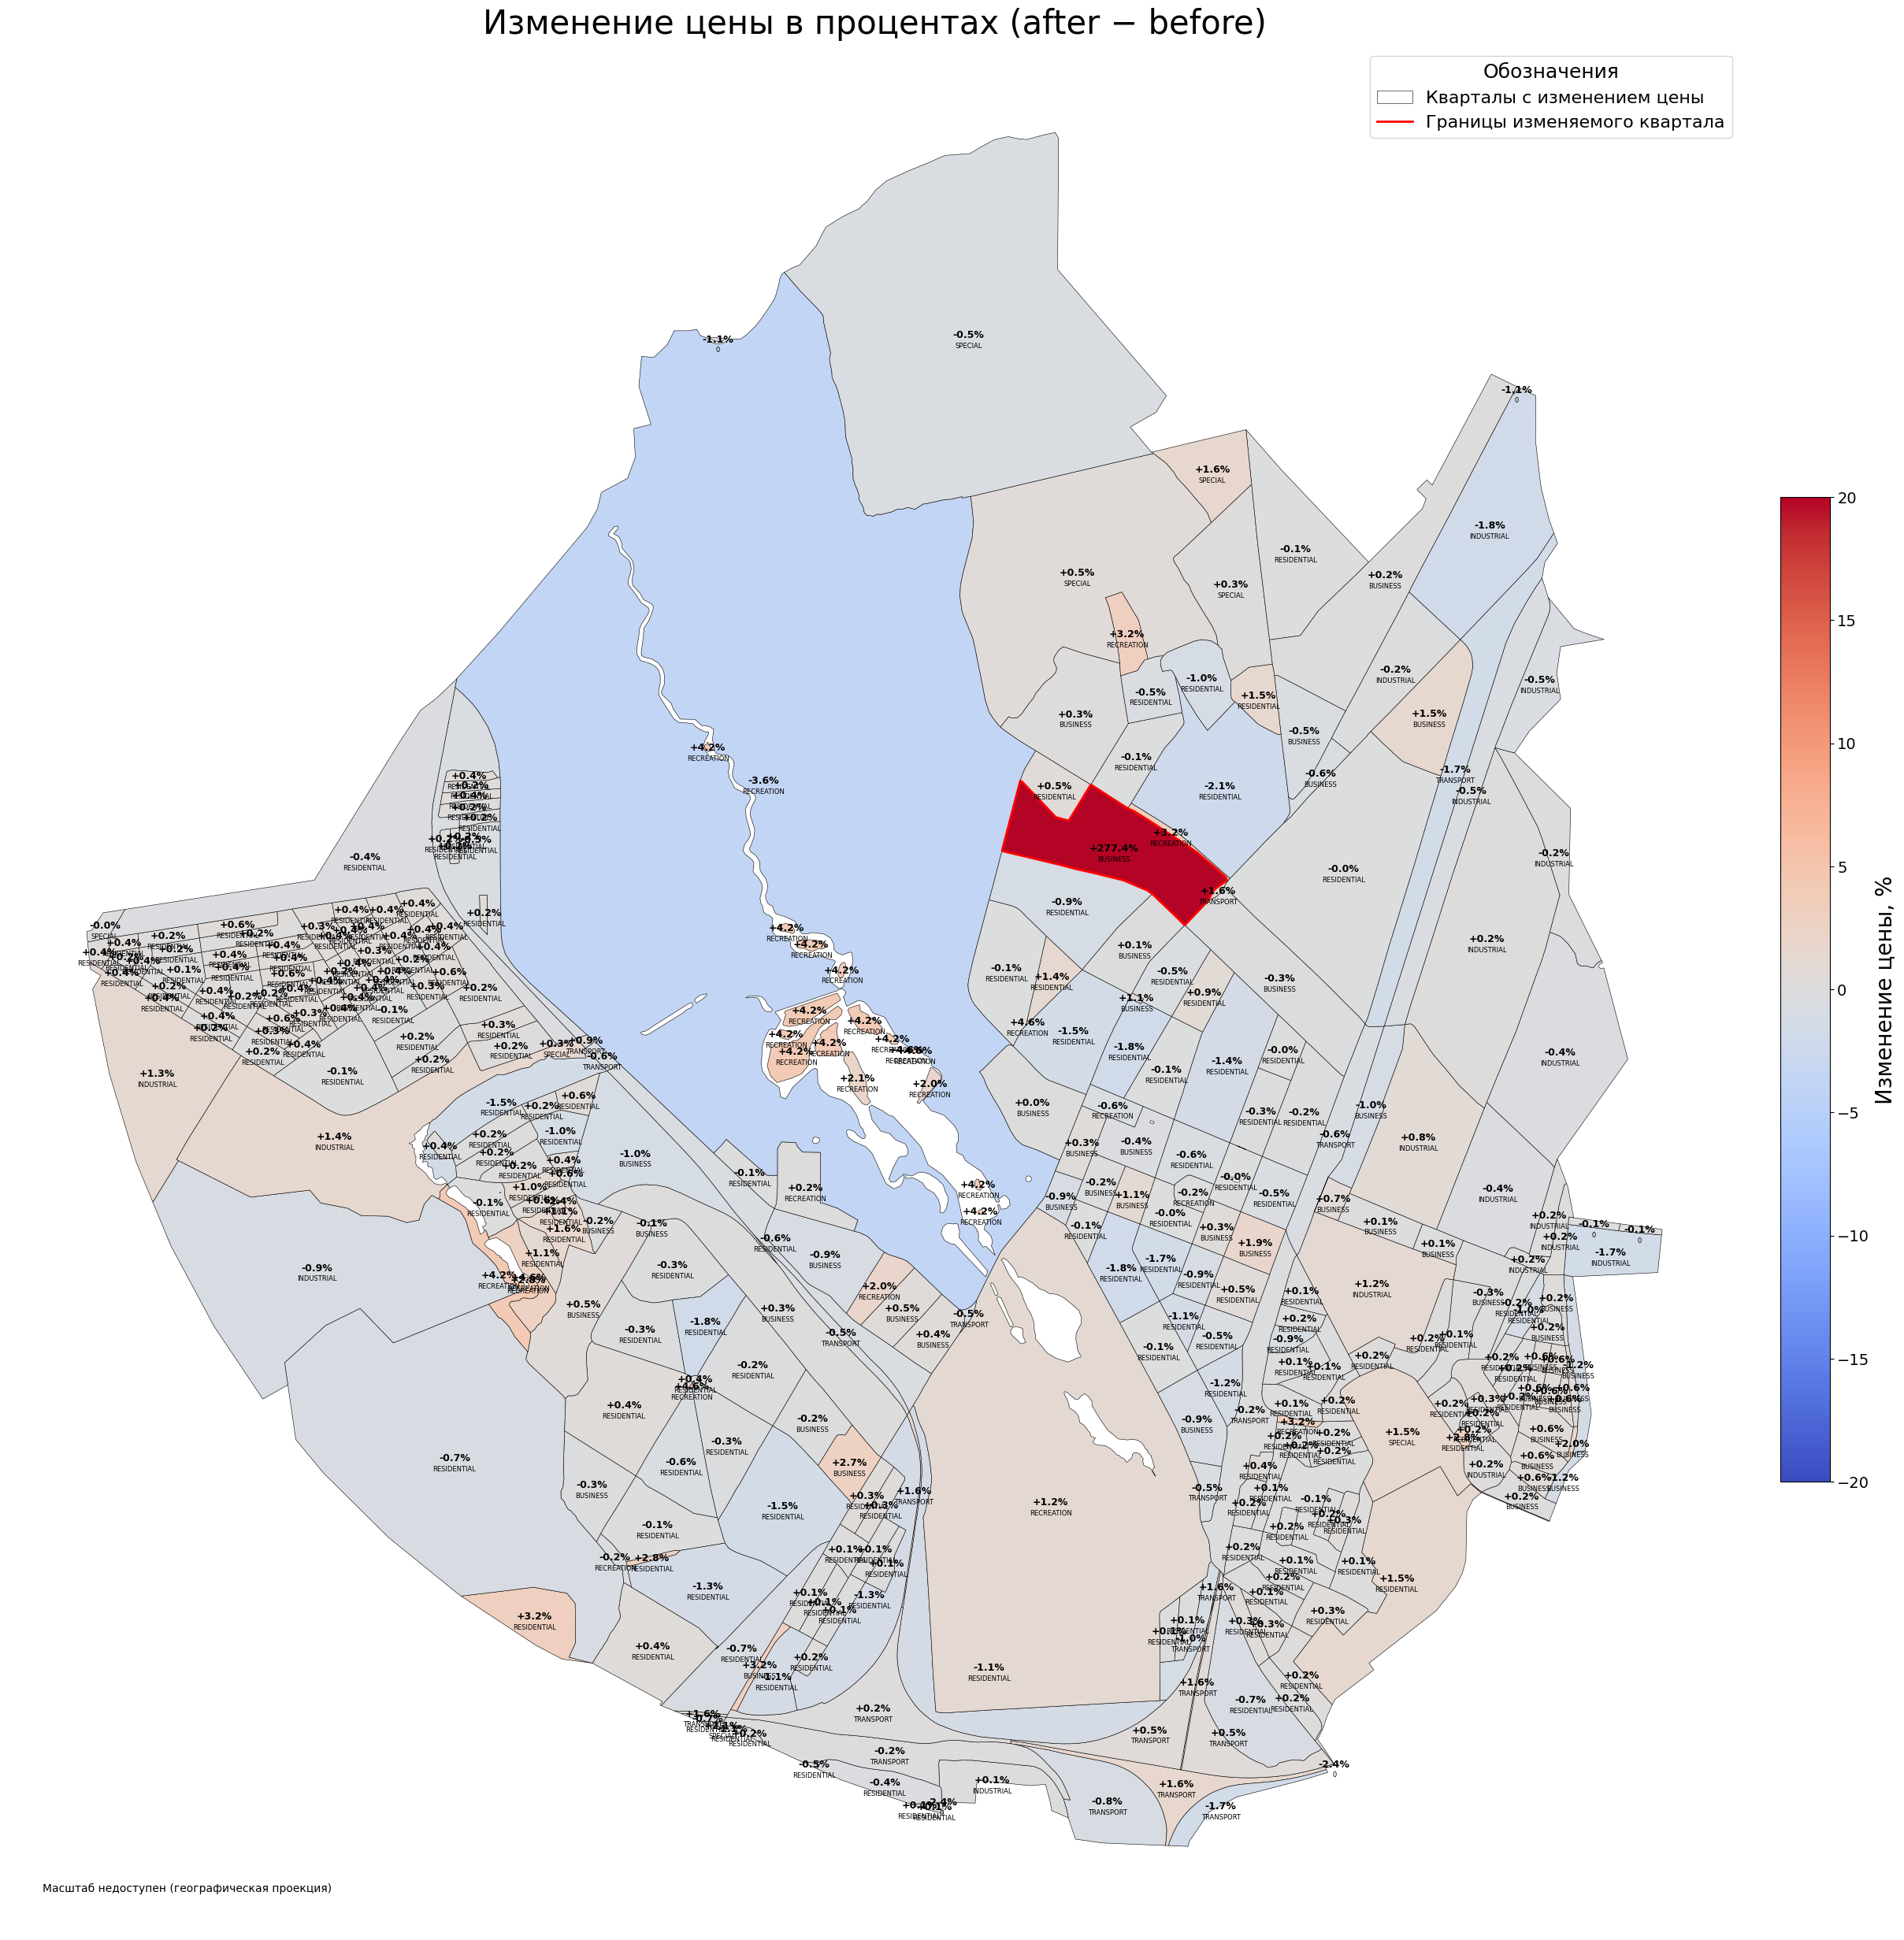


Статистика по кварталам в контексте (|Δ₽| > 1e-09):

Изменяемый квартал:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
86 | BUSINESS | 118 479 530 ₽ → 447 165 384 ₽ | +328 685 854 ₽ | +277.4%

Кварталы в границах проекта:
Нет кварталов проекта с изменениями выше порога.

Кварталы в контексте:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
245 | TRANSPORT | 269 491 595 ₽ → 267 230 431 ₽ | -2 261 164 ₽ | -0.8%
294 | TRANSPORT | 28 805 081 ₽ → 29 278 017 ₽ | +472 936 ₽ | +1.6%
115 | RESIDENTIAL | 54 358 090 ₽ → 54 414 357 ₽ | +56 267 ₽ | +0.1%
313 | RESIDENTIAL | 68 209 644 ₽ → 68 280 249 ₽ | +70 605 ₽ | +0.1%
308 | 0 | 13 692 ₽ → 13 362 ₽ | -330 ₽ | -2.4%
314 | INDUSTRIAL | 107 426 653 ₽ → 107 551 180 ₽ | +124 527 ₽ | +0.1%
224 | TRANSPORT | 105 411 805 ₽ → 105 939 347 ₽ | +527 542 ₽ | +0.5%
295 | TRANSPORT | 1 336 797 ₽ → 1 358 745 ₽ | +21 948 ₽ | +1.6%
5 | TRANSPORT | 65 767 573 ₽ → 65 092 073 ₽ | -675 500 ₽ | -1.0%
225 | TRANSPORT | 46 926 141 ₽ → 46 127 505 ₽ | -798 636 ₽ | -1.7%

In [19]:
blocks_full_value = transfer_baseline_prices(
    after_blocks=blocks_after_pred,
    before_blocks=blocks_before_pred,
    scenario_mode=False,
)

blocks_full_value = blocks_full_value.replace([np.inf, -np.inf], np.nan)
blocks_full_value = blocks_full_value.fillna(0)

# 3) Только визуализация и статистика по процентным изменениям
scenario_result = plot_scenario_impact(
    blocks=blocks_full_value,
    target_idx=target_idx,          
    target_id_column="id",   # если колонка называется иначе — укажи здесь
    figsize=(25, 35),
)

# Оптимизация агентами!

# **Инвестиционная** привлекактельтность 

In [20]:
blocks_after = blocks_after.copy()
blocks_after["is_project"] = False
blocks_after.loc[blocks_after["id"] == target_idx, "is_project"] = True


In [21]:
from blocksnet.enums import LandUse

benchmarks_ru = {
    LandUse.RESIDENTIAL: {
        "cost_build": 45_000,
        "price_sale": 140_000,
        "construction_years": 3,
        "sale_years": 4,
        "opex_rate": 800,
        "cost_demolition": 900,  # ₽/м² ориентировочно по России
    },
    LandUse.BUSINESS: {
        "cost_build": 55_000,
        "rent_annual": 25_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_300,
        "cost_demolition": 900,
    },
    LandUse.RECREATION: {
        "cost_build": 20_000,
        "rent_annual": 7_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_000,
        "cost_demolition": 900,
    },
    LandUse.SPECIAL: {
        "cost_build": 35_000,
        "rent_annual": 11_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_500,
        "cost_demolition": 900,
    },
    LandUse.INDUSTRIAL: {
        "cost_build": 38_000,
        "rent_annual": 14_800,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 700,
        "cost_demolition": 900,
    },
    LandUse.AGRICULTURE: {
        "cost_build": 25_000,
        "rent_annual": 6_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 300,
        "cost_demolition": 900,
    },
    LandUse.TRANSPORT: {
        "cost_build": 18_000,
        "rent_annual": 8_200,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 600,
        "cost_demolition": 900,
    },
}


In [22]:
from urbanomy.methods.investment_potential import prepare_investment_input


potential_df = pd.read_csv("./data/gatchina/land_use_potentials.csv")

investment_input = prepare_investment_input(
    gdf = blocks_after,
    project_potential = potential_df,
)

investment_input.head()

2026-03-04 20:32:28.812 | WARNING  | urbanomy.utils.investment_input:prepare_investment_input:455 - prepare_investment_input: колонка 'land_value_before' не найдена; значения скопированы из 'land_value'.


,land_use,land_value,land_value_before,site_area,living_area,non_living_area,build_floor_area,share,spatial_potential,land_use_before
0,LandUse.BUSINESS,4.369606e+08,4.369606e+08,262250.979778,44241.785252,62865.904925,107107.690178,0.648297,0.0,


In [23]:
from urbanomy.methods.investment_potential import InvestmentAttractivenessAnalyzer

an = InvestmentAttractivenessAnalyzer(benchmarks=benchmarks_ru)
summary = an.calculate_investment_metrics(investment_input, discount_rate=0.18)
summary

Project totals:
 • Land area:          262,250.98
 • Built area:         107,107.69
 • Land value:         436,960,559.91
 • Demolition cost:    96,396,921.16
 • Construction cost:  5,890,922,959.77
 • Investment need:    6,424,280,440.84
 • Spatial potential:  0.00
 • Project NPV:        363,677,302.05
 • Project IRR:        0.19
 • Project ROI:        8.34
 • Project PP (yrs):   14.86
 • Project EI:         52.48
 • Project INV score:  36.73


,land_use,land_area,land_value_before,built_area,land_value,demolition_cost,construction_cost,investment_need,NPV,IRR,ROI,PP_years,EI,spatial_potential,INV
0,LandUse.BUSINESS,262250.98,4.369606e+08,107107.69,4.369606e+08,96396921.16,5.890923e+09,6.424280e+09,3.636773e+08,0.19,8.34,14.86,52.48,0.0,36.73


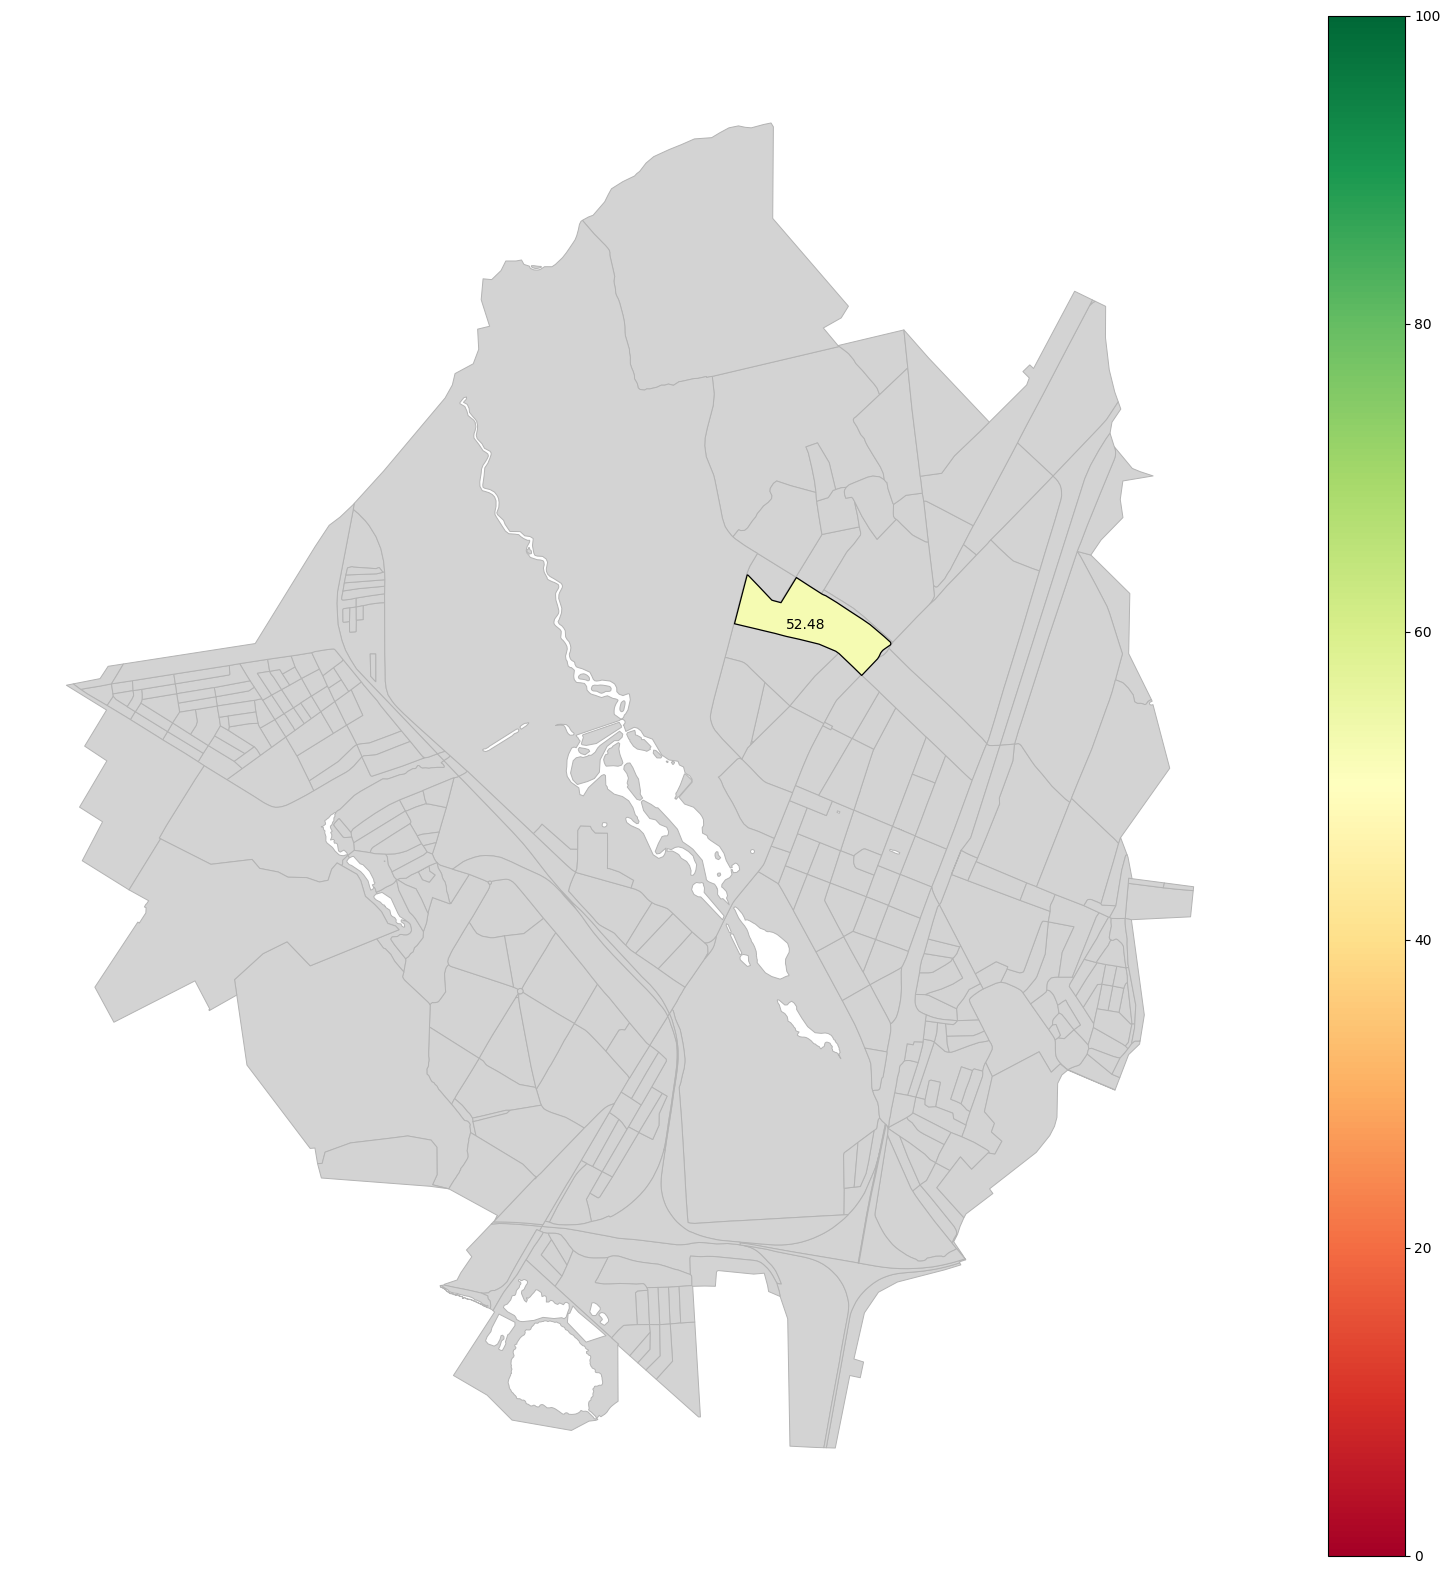

In [24]:
# 1) кладём summary на нужный индекс
summary_idxed = summary.copy()
summary_idxed.index = [target_idx]  # если одна строка; иначе set_index по id

# 2) собираем слой
scn = blocks_after[["geometry"]].join(summary_idxed, how="left")
scn["is_project"] = scn.index == target_idx

column = "EI"
vmin, vmax = 0, 100

fig, ax = plt.subplots(figsize=(20, 20))
scn.loc[~scn["is_project"]].plot(ax=ax, color="lightgrey", edgecolor="0.7", linewidth=0.7)

scn_proj = scn.loc[scn["is_project"]]
if len(scn_proj):
    scn_proj.plot(
        ax=ax,
        column=column,
        cmap="RdYlGn",
        legend=True,
        edgecolor="black",
        linewidth=0.9,
        vmin=vmin,
        vmax=vmax,
    )
    for _, row in scn_proj.dropna(subset=[column]).iterrows():
        x, y = row.geometry.representative_point().coords[0]
        ax.text(x, y, f"{row[column]:.2f}", ha="center", va="center", fontsize=10, color="black")

ax.set_axis_off()
plt.show()

In [25]:
from urbanomy.methods.socio_economic_indicators.sei_calculate import SEREstimator

deafaut_cfg = {
    "population": 91_000,
}

est = SEREstimator(deafaut_cfg) # or use project_cfg
result = est.compute(scn, pretty=True)
result

,indicator,delta_total
0,Объём инвестиций в основной капитал на душу на...,64 735
1,Валовый региональный продукт на душу населения,46 492
2,Доходы бюджета территории,1 181 811 971
3,Средний уровень заработной платы,1 390
4,Износ основного фонда (тыс. руб.),167 891


## Оптимизация пустого района

In [26]:
from urbanomy.methods.land_value_modeling.ga_mc_optimizer import DistrictProblem
# теперь оптимизируем пустой район генетикой!
target_idx = 86
site_area = float(blocks_clean["site_area"].iloc[86])


In [27]:
blocks_clean.iloc[7]

residential                                                           0.0
business                                                              0.0
recreation                                                            0.0
industrial                                                       0.727595
transport                                                        0.000757
special                                                          0.200502
agriculture                                                           0.0
land_use                                               LandUse.INDUSTRIAL
share                                                            0.727595
footprint_area                                                3990.876381
build_floor_area                                              3990.876381
living_area                                                           0.0
non_living_area                                               3990.876381
population                            

In [28]:
problem = DistrictProblem(
    blocks=blocks_clean,
    target_idx=target_idx,
    model=model,
    benchmarks=benchmarks_ru,
    potential_df=potential_df,
    
constraints = {
    "footprint_area": {"type": "float", "min": 0.0, "max": 0.1 * site_area},
    "l": {"type": "float", "min": 1.0, "max": 10.0},
    "mxi": {"type": "float", "min": 0.0, "max": 1.0},

    "residential": {"type": "float", "min": 0.0, "max": 1.0},
    "business": {"type": "float", "min": 0.0, "max": 1.0},
    "recreation": {"type": "float", "min": 0.0, "max": 1.0},
    "industrial": {"type": "float", "min": 0.0, "max": 1.0},
    "transport": {"type": "float", "min": 0.0, "max": 1.0},
    "special": {"type": "float", "min": 0.0, "max": 1.0},
    "agriculture": {"type": "float", "min": 0.0, "max": 1.0},
},
    
    estimator_kwargs={
        "orig_features": numeric_feats+cat_features,
        "categorical_features": cat_features,
    }
)

In [45]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

algorithm = NSGA2(
    pop_size=20,
    eliminate_duplicates=True,
)

res = minimize(
    problem,
    algorithm,
    ('n_gen', 25),
    seed=42,
    verbose=True,
    save_history=True,
)


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       20 |      3 |             - |             -
     2 |       40 |      7 |  0.6447761173 |         ideal
     3 |       60 |      6 |  0.0210565488 |         ideal
     4 |       80 |      8 |  0.0918881579 |         ideal
     5 |      100 |      8 |  0.0530183814 |         nadir
     6 |      120 |      7 |  0.0264604568 |         ideal
     7 |      140 |     12 |  0.2157392762 |         ideal
     8 |      160 |      5 |  0.0603073515 |         ideal
     9 |      180 |      6 |  0.0061157055 |         ideal
    10 |      200 |      7 |  0.0270504338 |         ideal
    11 |      220 |     11 |  0.0091674928 |             f
    12 |      240 |     12 |  0.0247207856 |             f
    13 |      260 |      7 |  0.1270607846 |         ideal
    14 |      280 |     11 |  0.0185716239 |         nadir
    15 |      300 |     17 |  0.0274057047 |         ideal
    16 |      320 |     16 |  0.0309800530 |         ide

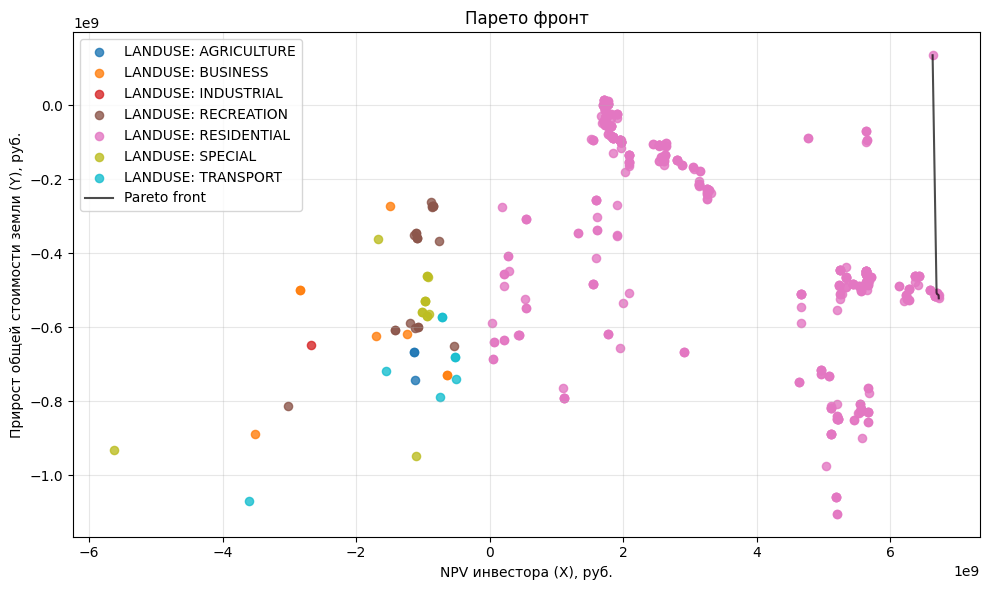

In [46]:
import numpy as np
import matplotlib.pyplot as plt

optimizer = problem

# 1) Базовая стоимость "до"
baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,
)

# 2) Собираем ВСЕ решения: из history (если optimize(..., save_history=True)), иначе из res.X/res.F
X_all, F_all = [], []
if getattr(res, "history", None):
    for alg in res.history:
        pop = alg.pop
        Xi, Fi = pop.get("X"), pop.get("F")
        if Xi is not None and Fi is not None and len(Xi):
            X_all.append(np.asarray(Xi))
            F_all.append(np.asarray(Fi))

if X_all:
    X = np.vstack(X_all)
    F = np.vstack(F_all)
else:
    X = np.asarray(res.X)
    F = np.asarray(res.F)

# 3) Цели
land_value_total = -F[:, 0]
admin_gain = land_value_total - baseline_land_value
investor_npv = -F[:, 1]

# 4) LANDUSE для каждого решения (через тот же repair, что в оптимизаторе)
landuse_labels = []
for genome_vec in X:
    changes = {name: genome_vec[j] for j, name in enumerate(optimizer.var_names)}
    repaired = optimizer._repair_genome(changes)   # использует логику из вашей задачи
    lu = repaired["land_use"]
    lu_name = getattr(lu, "name", str(lu).split(".")[-1])
    landuse_labels.append(lu_name)

landuse_labels = np.array(landuse_labels)
unique_lu = np.unique(landuse_labels)

# 5) Цвета + легенда
cmap = plt.get_cmap("tab10", len(unique_lu))
color_map = {lu: cmap(i) for i, lu in enumerate(unique_lu)}

plt.figure(figsize=(10, 6))

for lu in unique_lu:
    m = landuse_labels == lu
    plt.scatter(
        investor_npv[m],
        admin_gain[m],
        s=35,
        alpha=0.8,
        color=color_map[lu],
        label=f"LANDUSE: {lu}",
    )

# (опционально) поверх — линия самого Pareto-фронта из res.F
pf_x = -res.F[:, 1]
pf_y = -res.F[:, 0] - baseline_land_value
order = np.argsort(pf_x)
plt.plot(pf_x[order], pf_y[order], color="black", lw=1.5, alpha=0.7, label="Pareto front")

plt.xlabel("NPV инвестора (X), руб.")
plt.ylabel("Прирост общей стоимости земли (Y), руб.")
plt.title("Парето фронт")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()   


In [47]:
print("Лучшие решения (переменные):\n", res.X) # Массив решений на фронте Парето
print("Значения целевых функций:\n", -res.F)


Лучшие решения (переменные):
 [[2.60349637e+04 9.93347066e+00 7.34910654e-01 8.79843049e-01
  7.89493486e-01 6.41321101e-01 3.31439959e-01 4.73316352e-01
  4.43617811e-02 1.50654808e-02]
 [2.60541360e+04 9.93347066e+00 7.34910654e-01 9.55350113e-01
  7.89493486e-01 6.41321101e-01 3.31594134e-01 4.73316352e-01
  2.59536897e-02 1.09113051e-02]
 [2.61304628e+04 9.93926173e+00 6.96121556e-01 9.55728670e-01
  7.93426275e-01 6.54802778e-01 3.30605718e-01 1.99834346e-01
  4.37468614e-02 1.46694165e-02]
 [2.58600114e+04 9.91758690e+00 8.34681495e-01 9.54821580e-01
  7.89493486e-01 6.41060463e-01 2.91406832e-01 4.55250918e-01
  8.19013701e-02 1.86254580e-05]
 [2.61076747e+04 9.95174934e+00 6.91465613e-01 9.62622142e-01
  7.90206550e-01 5.62898117e-01 1.99200439e-01 1.99771917e-01
  3.98715981e-02 9.91088623e-04]]
Значения целевых функций:
 [[3.85211483e+10 6.69788854e+09]
 [3.85180670e+10 6.70314270e+09]
 [3.85144303e+10 6.72823473e+09]
 [3.91630130e+10 6.63861104e+09]
 [3.85059011e+10 6.730980

In [48]:
len(res.opt)

5

In [49]:
import numpy as np

# т.к. F минимизируется, а ты пишешь F[:,0] = -land_value
idx_city = np.argmin(res.F[:, 0])   # максимум land_value
params_optimal = {p: res.X[idx_city][i] for i, p in enumerate(problem.constraints.keys())}
params_optimal

{'footprint_area': np.float64(25860.011422257852),
 'l': np.float64(9.917586897019142),
 'mxi': np.float64(0.8346814949550003),
 'residential': np.float64(0.9548215801711482),
 'business': np.float64(0.7894934864035812),
 'recreation': np.float64(0.6410604627350315),
 'industrial': np.float64(0.2914068318222971),
 'transport': np.float64(0.45525091794647543),
 'special': np.float64(0.08190137014906783),
 'agriculture': np.float64(1.862545798944626e-05)}

In [35]:
params_optimal = {param: res.X[3][i] for i, param in enumerate(problem.constraints.keys())}
params_optimal

{'footprint_area': np.float64(18679.782372806447),
 'l': np.float64(6.352766787868953),
 'mxi': np.float64(0.07946879866754022),
 'residential': np.float64(0.9645175849868193),
 'business': np.float64(0.7008951498962122),
 'recreation': np.float64(0.662522284353982),
 'industrial': np.float64(0.31171107608941095),
 'transport': np.float64(0.5204500204216347),
 'special': np.float64(0.5523589734513723),
 'agriculture': np.float64(0.028258600053707963)}

In [50]:
params_repaired = problem._repair_genome(params_optimal)
params_repaired

{'footprint_area': 25860.011422257852,
 'l': 9.917586897019142,
 'mxi': 0.8346814949550003,
 'residential': 0.29708632906760446,
 'business': 0.24564560182686992,
 'recreation': 0.1994616623036451,
 'industrial': 0.09066928076320724,
 'transport': 0.14164826898144964,
 'special': 0.025483061870922797,
 'agriculture': 5.7951863009795376e-06,
 'share': 0.29708632906760446,
 'land_use': <LandUse.RESIDENTIAL: 'residential'>,
 'build_floor_area': 256468.91043814982,
 'living_area': 214069.85357399497,
 'non_living_area': 42399.056864154845,
 'population': 10703.49267869975,
 'fsi': 0.9779521535256542,
 'gsi': 0.09860787343538076,
 'morphotype': 'high-rise soviet microdistrict'}

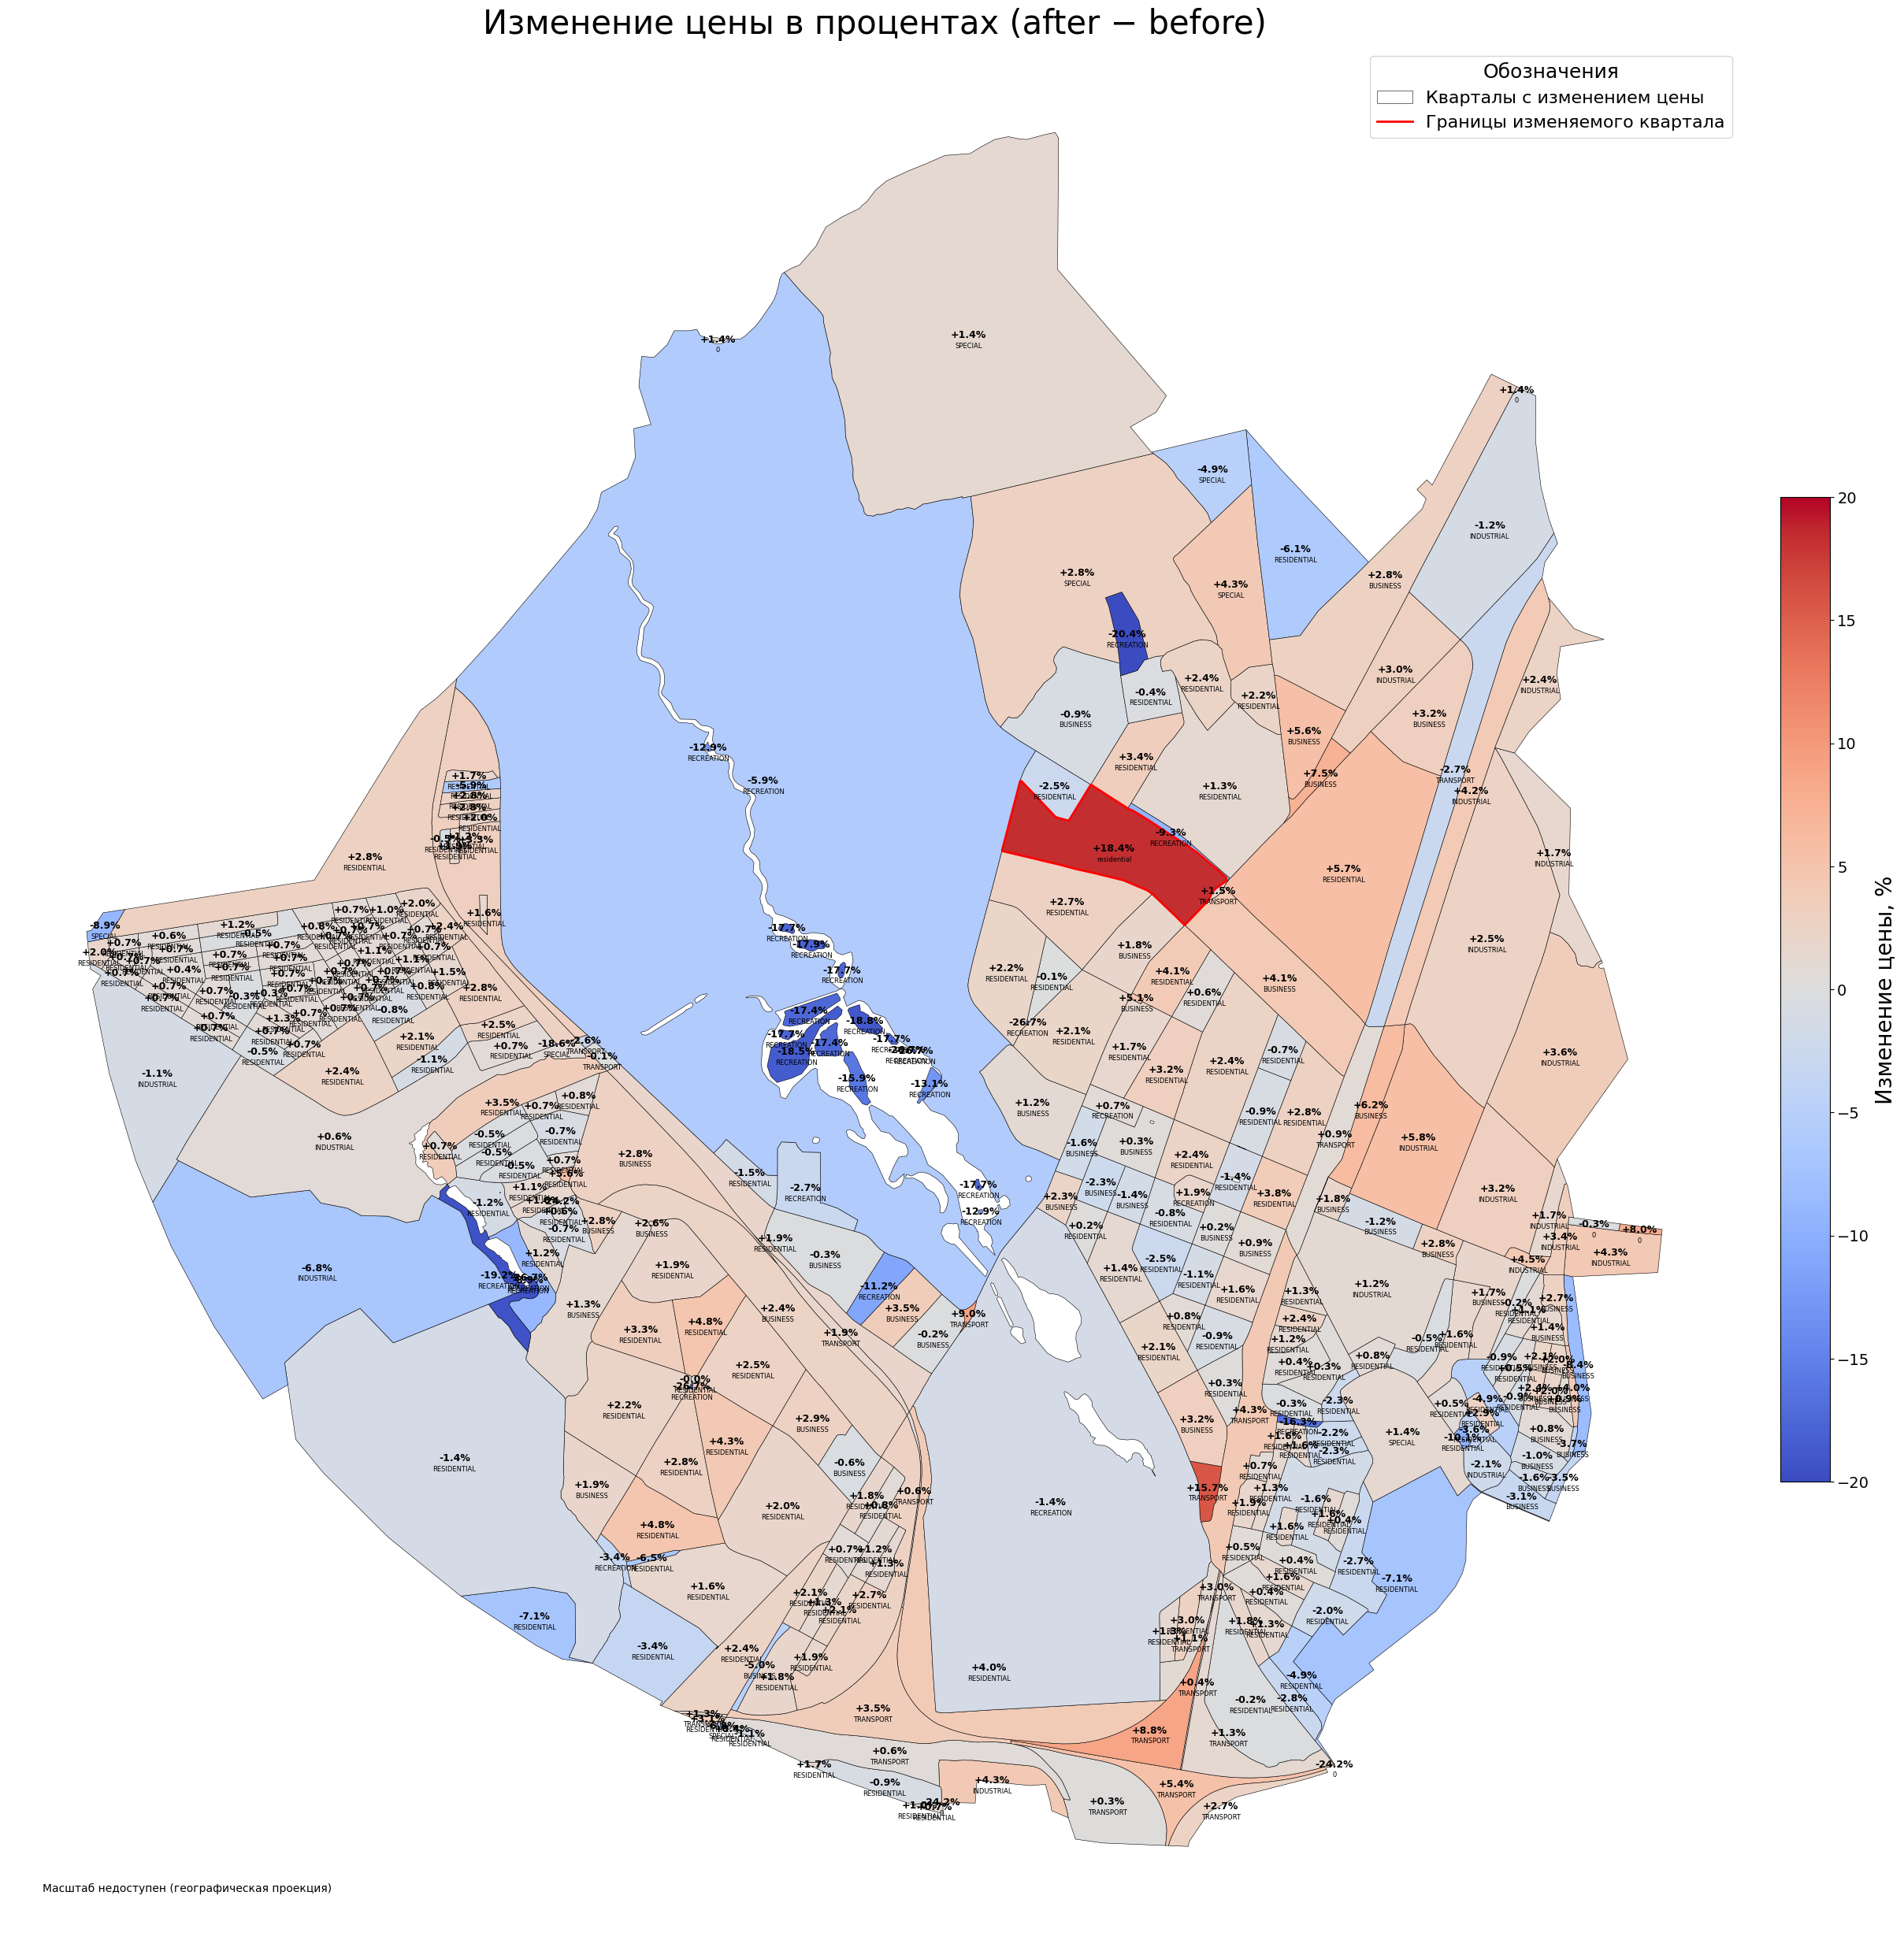


Статистика по кварталам в контексте (|Δ₽| > 1e-09):

Изменяемый квартал:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
86 | residential | 436 960 560 ₽ → 517 297 118 ₽ | +80 336 558 ₽ | +18.4%

Кварталы в границах проекта:
Нет кварталов проекта с изменениями выше порога.

Кварталы в контексте:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
245 | TRANSPORT | 267 403 995 ₽ → 268 094 342 ₽ | +690 347 ₽ | +0.3%
294 | TRANSPORT | 27 800 270 ₽ → 29 306 490 ₽ | +1 506 220 ₽ | +5.4%
115 | RESIDENTIAL | 53 267 525 ₽ → 53 801 266 ₽ | +533 741 ₽ | +1.0%
313 | RESIDENTIAL | 67 063 990 ₽ → 67 535 414 ₽ | +471 424 ₽ | +0.7%
308 | 0 | 16 305 ₽ → 12 352 ₽ | -3 953 ₽ | -24.2%
314 | INDUSTRIAL | 102 654 801 ₽ → 107 108 961 ₽ | +4 454 160 ₽ | +4.3%
224 | TRANSPORT | 97 458 015 ₽ → 106 013 438 ₽ | +8 555 423 ₽ | +8.8%
295 | TRANSPORT | 1 417 821 ₽ → 1 424 017 ₽ | +6 196 ₽ | +0.4%
5 | TRANSPORT | 64 537 025 ₽ → 65 235 493 ₽ | +698 468 ₽ | +1.1%
225 | TRANSPORT | 46 031 959 ₽ → 47 253 225 ₽ | +1 221 266

In [51]:
from urbanomy.methods.land_value_modeling import LandPriceEstimator

# 1) Применяем сценарные изменения к признакам блока
blocks_after_scenario = modifier.apply(target_idx, params_repaired)

# 2) Предсказываем новую стоимость земли для сценария
scenario_estimator = LandPriceEstimator(
    model=model,
    blocks=blocks_after_scenario,
    use_service_features=False,
)
blocks_after_scenario_pred = scenario_estimator.predict()
blocks_after_scenario_pred["land_value_per_100m2"] = (
    blocks_after_scenario_pred["land_value"] / blocks_after_scenario_pred["site_area"] * 100
)

# 3) Базовый набор "до" тоже должен содержать land_value
if "land_value" in blocks_after.columns:
    blocks_before_pred = blocks_after.copy()
else:
    baseline_estimator = LandPriceEstimator(
        model=model,
        blocks=blocks_after,
        use_service_features=False,
    )
    blocks_before_pred = baseline_estimator.predict()

if "land_value_per_100m2" not in blocks_before_pred.columns:
    blocks_before_pred["land_value_per_100m2"] = (
        blocks_before_pred["land_value"] / blocks_before_pred["site_area"] * 100
    )

# 4) Переносим baseline-цену в колонку land_value_before
blocks_full_value = transfer_baseline_prices(
    after_blocks=blocks_after_scenario_pred,
    before_blocks=blocks_before_pred,
    scenario_mode=False,
)

blocks_full_value = blocks_full_value.replace([np.inf, -np.inf], np.nan)
blocks_full_value = blocks_full_value.fillna(0)

# 5) Визуализация и статистика изменений
scenario_result = plot_scenario_impact(
    blocks=blocks_full_value,
    target_idx=target_idx,
    target_id_column="id",
    figsize=(25, 35),
)


In [52]:
import pandas as pd

blocks_gen = modifier.apply(target_idx, params_repaired)   # без запятой

gen_blocks = pd.DataFrame(blocks_gen)

gen_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,l,morphotype,area_accessibility,geometry,site_area,land_value,land_value_per_100m2,id,share_living,share_non_living
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,1.371459,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",215420.389645,2.918098e+08,135460.608081,0,NaN,NaN
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,5.824002,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",108166.972589,3.119623e+08,288408.099091,1,NaN,NaN
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,5.365401,mid-rise,8.669212,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",77911.495727,2.421744e+08,310832.641384,2,NaN,NaN
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,2.288643,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",32058.270586,8.120294e+07,253297.930854,3,NaN,NaN
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,2.187029,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",30779.356283,7.602283e+07,246992.918836,4,NaN,NaN


In [57]:
gen_blocks.iloc[86]

residential                                                      0.297086
business                                                         0.245646
recreation                                                       0.199462
industrial                                                       0.090669
transport                                                        0.141648
special                                                          0.025483
agriculture                                                      0.000006
land_use                                              LandUse.RESIDENTIAL
share                                                            0.297086
footprint_area                                               25860.011422
build_floor_area                                            256468.910438
living_area                                                 214069.853574
non_living_area                                              42399.056864
population                            

In [58]:
blocks_after.iloc[86]

residential                                                      0.268468
business                                                         0.648297
recreation                                                       0.065871
industrial                                                            0.0
transport                                                         0.01739
special                                                               0.0
agriculture                                                           0.0
land_use                                                 LandUse.BUSINESS
share                                                            0.648297
footprint_area                                               47096.975151
build_floor_area                                            107107.690178
living_area                                                  44241.785252
non_living_area                                              62865.904925
population                            

In [54]:
gen_blocks = gen_blocks.copy()
gen_blocks["is_project"] = False

# target_idx — индекс изменяемого квартала
if target_idx in gen_blocks.index:
    gen_blocks.loc[target_idx, "is_project"] = True
else:
    raise KeyError(f"target_idx={target_idx} не найден в gen_blocks.index")

investment_input = prepare_investment_input(
    gdf=gen_blocks,
    project_potential=potential_df,
)

summary = an.calculate_investment_metrics(
    investment_input,
    discount_rate=0.18,
    show_project_totals=True
)
summary

2026-03-04 20:53:25.214 | WARNING  | urbanomy.utils.investment_input:prepare_investment_input:455 - prepare_investment_input: колонка 'land_value_before' не найдена; значения скопированы из 'land_value'.


Project totals:
 • Land area:          262,250.98
 • Built area:         256,468.91
 • Land value:         436,960,559.91
 • Demolition cost:    230,822,019.39
 • Construction cost:  11,541,100,969.72
 • Investment need:    12,208,883,549.02
 • Spatial potential:  0.00
 • Project NPV:        6,638,611,036.98
 • Project IRR:        0.37
 • Project ROI:        6.39
 • Project PP (yrs):   5.12
 • Project EI:         100.00
 • Project INV score:  60.00


,land_use,land_area,land_value_before,built_area,land_value,demolition_cost,construction_cost,investment_need,NPV,IRR,ROI,PP_years,EI,spatial_potential,INV
0,LandUse.RESIDENTIAL,262250.98,4.369606e+08,256468.91,4.369606e+08,2.308220e+08,1.154110e+10,1.220888e+10,6.638611e+09,0.37,6.39,5.12,100.0,0.0,60.0


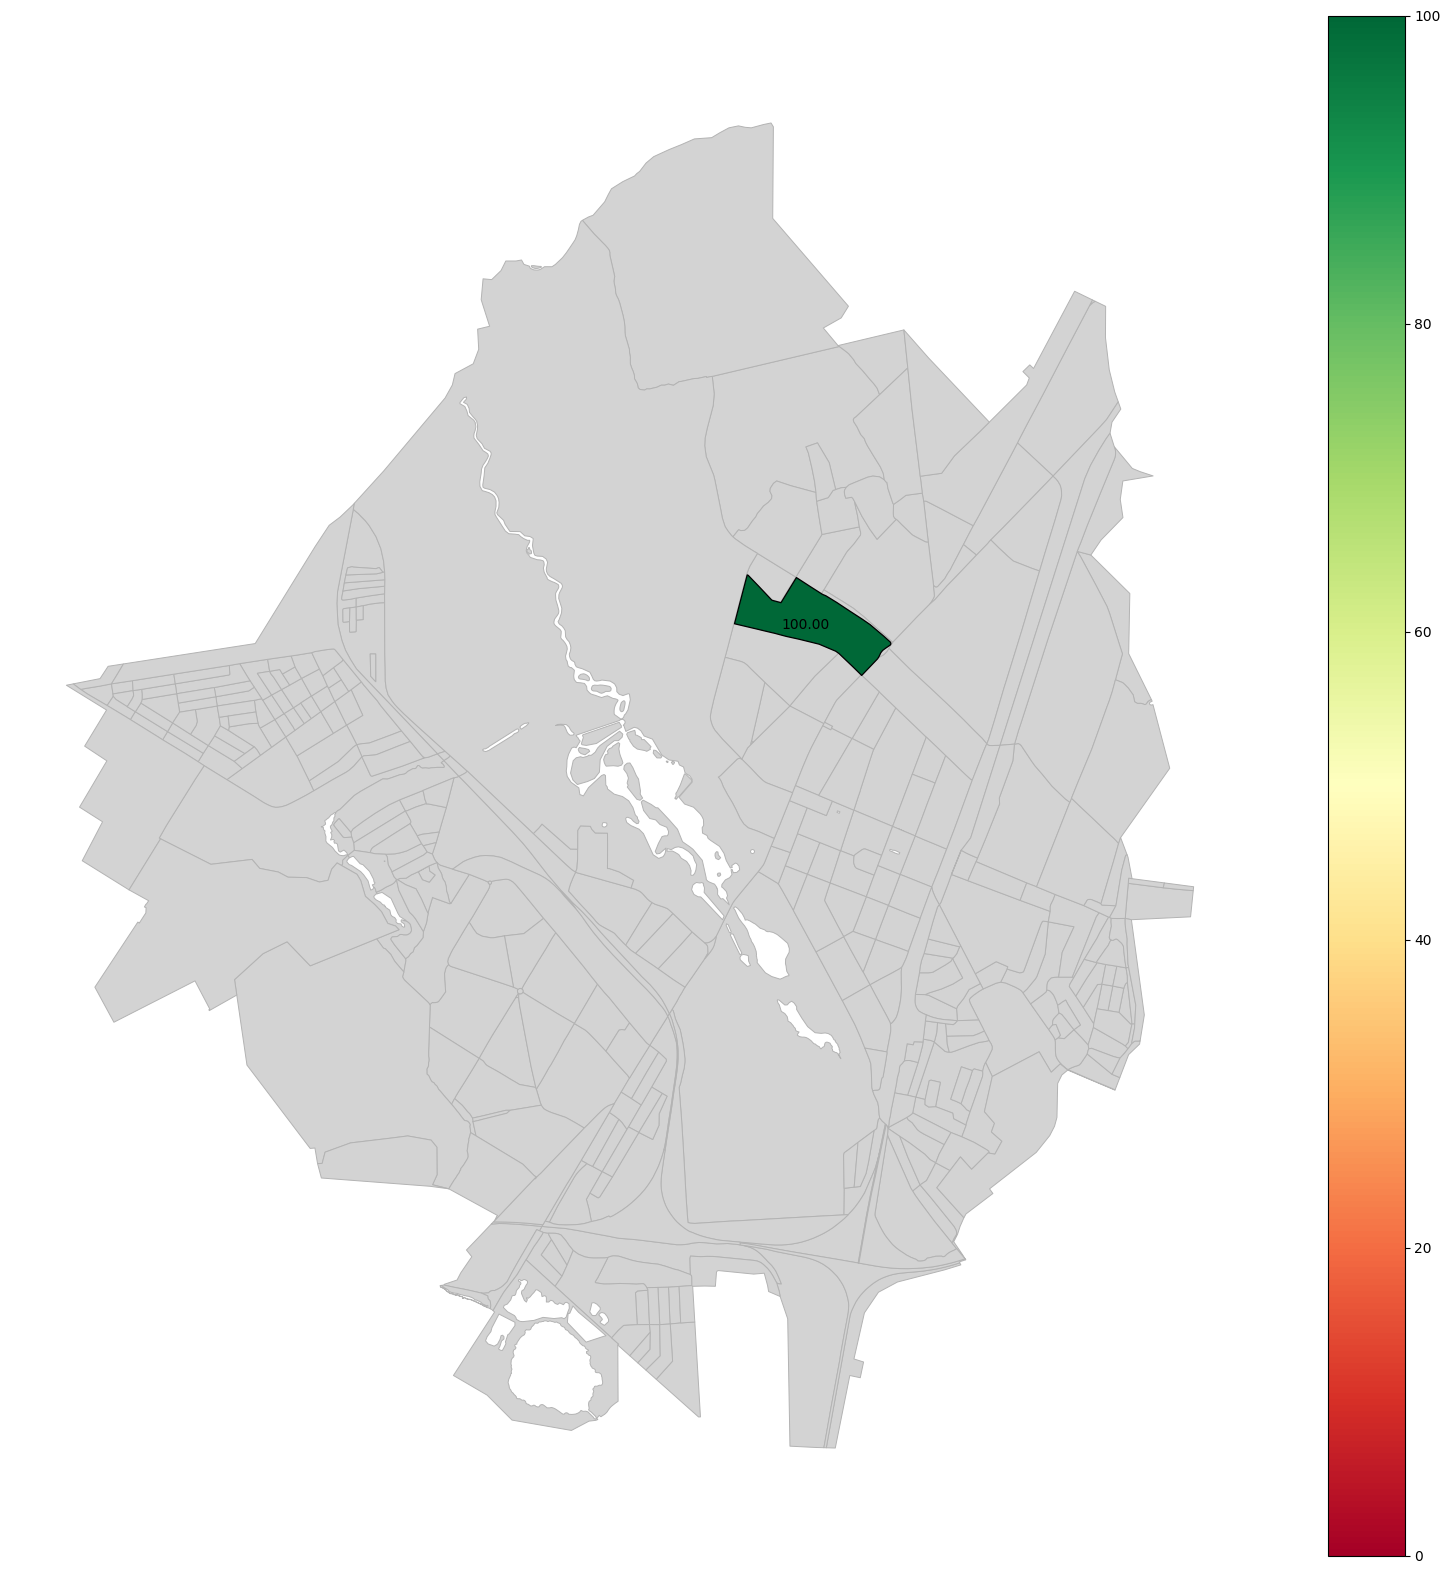

In [42]:
# 1) кладём summary на нужный индекс
summary_idxed = summary.copy()
summary_idxed.index = [target_idx]  # если одна строка; иначе set_index по id

# 2) собираем слой
scn = blocks_after[["geometry"]].join(summary_idxed, how="left")
scn["is_project"] = scn.index == target_idx

column = "EI"
vmin, vmax = 0, 100

fig, ax = plt.subplots(figsize=(20, 20))
scn.loc[~scn["is_project"]].plot(ax=ax, color="lightgrey", edgecolor="0.7", linewidth=0.7)

scn_proj = scn.loc[scn["is_project"]]
if len(scn_proj):
    scn_proj.plot(
        ax=ax,
        column=column,
        cmap="RdYlGn",
        legend=True,
        edgecolor="black",
        linewidth=0.9,
        vmin=vmin,
        vmax=vmax,
    )
    for _, row in scn_proj.dropna(subset=[column]).iterrows():
        x, y = row.geometry.representative_point().coords[0]
        ax.text(x, y, f"{row[column]:.2f}", ha="center", va="center", fontsize=10, color="black")

ax.set_axis_off()
plt.show()

In [43]:
from urbanomy.methods.socio_economic_indicators.sei_calculate import SEREstimator

deafaut_cfg = {
    "population": 91_000,
}

est = SEREstimator(deafaut_cfg) # or use project_cfg
result = est.compute(scn, pretty=True)
result

,indicator,delta_total
0,Объём инвестиций в основной капитал на душу на...,58 682
1,Валовый региональный продукт на душу населения,29 015
2,Доходы бюджета территории,320 404 413
3,Средний уровень заработной платы,0.0000
4,Износ основного фонда (тыс. руб.),152 192
